In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
path = "C://Users//shadj//Desktop//Research//Code//app_data.xlsx"
df = pd.read_excel(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    object 
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Management                        781 non-null    object 
 7   Severity                          781 non-null    object 
 8   Diagnosis_Presumptive             780 non-null    object 
 9   Diagnosis                         780 non-null    object 
 10  Alvarado_Score                    730 non-null    float64
 11  Paedriatic_Appendicitis_Score     730 non-null    float64
 12  Appendix

In [3]:
df["Diagnosis"].value_counts()

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [4]:
df.shape

(782, 58)

In [5]:
# from sklearn.model_selection import train_test_split
# df.loc[:,"Diagnosis"].dropna(inplace=True)
# df["Diagnosis"].value_counts(dropna=False)
# #df["Diagnosis"] = df[df["Diagnosis"]=="appendicitis"].astype(int)

In [6]:
#checking the value of Diagnosis Column
df['Diagnosis'].value_counts(dropna = False)


appendicitis       463
no appendicitis    317
NaN                  2
Name: Diagnosis, dtype: int64

In [7]:
# removing the rows whose diagnosis column is nan
df = df[df['Diagnosis'].notna()]
df['Diagnosis'].value_counts(dropna = False)

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [8]:
#converting the diagnosis value to int type
df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)

In [9]:
# correlation of different columns with each other
df.corr()

C:\Users\shadj\AppData\Local\Temp\ipykernel_25088\3540467011.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,Age,BMI,Height,Weight,Length_of_Stay,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP,US_Number
Age,1.000000,0.480260,0.865212,0.766366,-0.103958,-0.088758,-0.181370,-0.127890,-0.030214,-0.290765,-0.248400,-0.177806,-0.450627,0.043015,0.256888,-0.011832,-0.261943,-0.130322,0.046207
BMI,0.480260,1.000000,0.462740,0.859202,-0.045762,-0.124772,-0.121359,-0.100005,0.040996,-0.151558,-0.122949,-0.183794,-0.217881,0.073769,0.175787,0.024529,-0.035245,-0.068655,0.043407
Height,0.865212,0.462740,1.000000,0.829438,-0.108980,-0.064345,-0.134157,-0.107983,-0.006397,-0.232372,-0.201797,-0.129100,-0.346772,0.078383,0.375145,-0.021228,-0.274992,-0.128182,0.002838
Weight,0.766366,0.859202,0.829438,1.000000,-0.066928,-0.099791,-0.146741,-0.121757,0.037628,-0.210826,-0.179033,-0.184130,-0.284693,0.089732,0.239662,0.003105,-0.172860,-0.092634,0.023028
Length_of_Stay,-0.103958,-0.045762,-0.108980,-0.066928,1.000000,0.385103,0.310115,0.227738,0.301530,0.226218,0.300919,0.233578,0.129662,-0.083149,-0.073525,0.084017,0.099924,0.524018,-0.118864
Diagnosis,-0.088758,-0.124772,-0.064345,-0.099791,0.385103,1.000000,0.419104,0.350888,0.629298,0.155629,0.361929,0.354624,0.538303,-0.026141,0.001865,0.057883,0.008935,0.284090,-0.241541
Alvarado_Score,-0.181370,-0.121359,-0.134157,-0.146741,0.310115,0.419104,1.000000,0.832473,0.337497,0.376022,0.639642,0.701133,0.699436,-0.006242,-0.052610,0.059918,0.068806,0.332292,-0.059370
Paedriatic_Appendicitis_Score,-0.127890,-0.100005,-0.107983,-0.121757,0.227738,0.350888,0.832473,1.000000,0.264968,0.299691,0.486760,0.554610,0.508287,-0.005896,-0.056656,0.020818,0.033673,0.266233,0.026625
Appendix_Diameter,-0.030214,0.040996,-0.006397,0.037628,0.301530,0.629298,0.337497,0.264968,1.000000,0.086271,0.333982,0.340236,0.373796,-0.063712,-0.004960,0.065832,0.039110,0.268492,-0.092364
Body_Temperature,-0.290765,-0.151558,-0.232372,-0.210826,0.226218,0.155629,0.376022,0.299691,0.086271,1.000000,0.273795,0.316383,0.152790,-0.038630,-0.071117,-0.010618,0.012231,0.318427,-0.231202


In [10]:
#  correlation of our output column with other columns
df.corr()['Diagnosis']

C:\Users\shadj\AppData\Local\Temp\ipykernel_25088\3928385209.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()['Diagnosis']


Age                             -0.088758
BMI                             -0.124772
Height                          -0.064345
Weight                          -0.099791
Length_of_Stay                   0.385103
Diagnosis                        1.000000
Alvarado_Score                   0.419104
Paedriatic_Appendicitis_Score    0.350888
Appendix_Diameter                0.629298
Body_Temperature                 0.155629
WBC_Count                        0.361929
Neutrophil_Percentage            0.354624
Segmented_Neutrophils            0.538303
RBC_Count                       -0.026141
Hemoglobin                       0.001865
RDW                              0.057883
Thrombocyte_Count                0.008935
CRP                              0.284090
US_Number                       -0.241541
Name: Diagnosis, dtype: float64

In [11]:
# list of columns with contains data of the ultrasound and have very few non na values
US_columns = ['US_Performed','Appendix_on_US','US_Number','Appendix_Wall_Layers','Target_Sign','Perfusion',"Surrounding_Tissue_Reaction",
              "Pathological_Lymph_Nodes","Lymph_Nodes_Location","Bowel_Wall_Thickening","Ileus","Coprostasis","Meteorism","Enteritis","Appendicolith",
               "Perforation","Appendicular_Abscess","Abscess_Location","Conglomerate_of_Bowel_Loops","Gynecological_Findings"]

In [12]:
# since this is early diagnosing therfore assuming that the US is not performed
# Hence removing all the columns that contains information of an ultrasound
df.drop(US_columns,axis=1,inplace=True)

In [13]:
df

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,3.0,conservative,uncomplicated,appendicitis,1,...,++,+,no,0.0,no,normal,no,yes,no,no
1,14.100000,31.900000,male,147.0,69.5,2.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,yes,normal,no,yes,no,no
2,14.140000,23.300000,female,163.0,62.0,4.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,no,constipation,no,yes,no,no
3,16.370000,20.600000,female,165.0,56.0,3.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,0.0,yes,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,3.0,conservative,uncomplicated,appendicitis,1,...,no,no,no,0.0,no,constipation,no,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,12.413415,25.250476,female,166.5,70.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,NaN,NaN,NaN,71.0,no,diarrhea,local,yes,NaN,no
778,17.092402,20.429418,female,158.0,51.0,6.0,secondary surgical,complicated,appendicitis,1,...,NaN,NaN,NaN,245.0,no,normal,local,no,NaN,no
779,14.992471,19.909972,female,152.0,46.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,no,no,no,2.0,yes,normal,no,no,no,yes
780,7.195072,14.295549,male,129.3,23.9,5.0,primary surgical,uncomplicated,appendicitis,1,...,+++,no,no,8.0,no,normal,local,no,no,yes


In [14]:
#This is the list of other target or output columns
target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]

In [15]:
# REmoving other target columns since they are not necessary
df.drop(target_cols,axis=1,inplace =True)

In [16]:
#information of the remaining dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [17]:
#removing the "Segmented_Neutrophils" Column, Since it had very few values
df.drop("Segmented_Neutrophils",axis=1,inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

<h2>Selecting only those rows which have no nan values : </h2>

In [19]:
df2 = df.dropna().copy()

In [20]:
df2

,Age,BMI,Sex,Height,Weight,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Migratory_Pain,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,1,4.0,3.0,7.1,no,...,++,+,no,0.0,no,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,1,5.0,6.0,7.0,no,...,no,no,no,0.0,no,constipation,no,yes,no,no
8,7.900000,15.700000,male,131.0,26.7,0,7.0,6.0,3.7,no,...,+++,+,no,20.0,no,normal,no,no,no,yes
9,14.340000,14.900000,male,174.0,45.5,1,4.0,4.0,8.0,no,...,no,no,no,0.0,no,normal,no,no,no,no
10,11.870000,15.700000,male,147.0,34.0,1,8.0,9.0,9.0,yes,...,no,no,no,17.0,no,normal,no,no,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,12.470910,15.373934,female,142.0,31.0,1,9.0,6.0,7.0,yes,...,no,no,no,0.0,no,normal,local,yes,no,yes
754,13.828884,23.828125,male,160.0,61.0,1,6.0,4.0,12.0,no,...,no,no,no,4.0,no,normal,local,yes,no,no
764,7.990000,13.550000,female,128.0,22.1,1,5.0,4.0,5.0,no,...,+++,no,no,0.0,no,constipation,no,no,no,no
768,11.548255,17.529432,female,152.0,40.5,1,9.0,7.0,10.0,no,...,+++,+,no,5.0,no,diarrhea,local,no,no,yes


In [21]:
df2.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Diagnosis', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness',
       'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature',
       'WBC_Count', 'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count',
       'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine',
       'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool',
       'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness',
       'Free_Fluids'],
      dtype='object')

In [22]:
df2["WBC_in_Urine"].value_counts()

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [23]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [24]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [26]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [27]:
df2["Sex"] = (df["Sex"]=="male").astype(int)

In [28]:
df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [30]:
df2["Lower_Right_Abd_Pain"].value_counts()

yes    228
no      10
Name: Lower_Right_Abd_Pain, dtype: int64

In [31]:
df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
df2["Lower_Right_Abd_Pain"].value_counts()

1    228
0     10
Name: Lower_Right_Abd_Pain, dtype: int64

In [32]:
df2["Contralateral_Rebound_Tenderness"].value_counts()

no     149
yes     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [33]:
df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
df2['Contralateral_Rebound_Tenderness'].value_counts()

0    149
1     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [34]:
df2["Coughing_Pain"].value_counts(dropna = False)

no     163
yes     75
Name: Coughing_Pain, dtype: int64

In [35]:
df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
df2["Coughing_Pain"].value_counts()

0    163
1     75
Name: Coughing_Pain, dtype: int64

In [36]:
df2["Nausea"].value_counts(dropna = False)

yes    132
no     106
Name: Nausea, dtype: int64

In [37]:
df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
df2["Nausea"].value_counts()

1    132
0    106
Name: Nausea, dtype: int64

In [38]:
df2["Loss_of_Appetite"].value_counts(dropna= False)

yes    121
no     117
Name: Loss_of_Appetite, dtype: int64

In [39]:
df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
df2["Loss_of_Appetite"].value_counts()

1    121
0    117
Name: Loss_of_Appetite, dtype: int64

In [40]:
df2["Neutrophilia"].value_counts(dropna = False)

no     138
yes    100
Name: Neutrophilia, dtype: int64

In [41]:
df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
df2["Neutrophilia"].value_counts()

0    138
1    100
Name: Neutrophilia, dtype: int64

In [42]:
df2["Ketones_in_Urine"].value_counts(dropna = False)

no     148
+++     47
+       29
++      14
Name: Ketones_in_Urine, dtype: int64

In [43]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)

0.0    148
3.0     47
1.0     29
2.0     14
Name: Ketones_in_Urine, dtype: int64

In [44]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [45]:
df2["RBC_in_Urine"].value_counts(dropna = False)

no     190
+       37
+++      7
++       4
Name: RBC_in_Urine, dtype: int64

In [46]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
df2["RBC_in_Urine"].value_counts(dropna = False)

0.0    190
1.0     37
3.0      7
2.0      4
Name: RBC_in_Urine, dtype: int64

In [47]:
df2["WBC_in_Urine"].value_counts(dropna= False)

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [48]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
df2["WBC_in_Urine"].value_counts(dropna = False)

0.0    206
1.0     22
2.0      7
3.0      3
Name: WBC_in_Urine, dtype: int64

In [49]:
df2["Dysuria"].value_counts(dropna= False)

no     227
yes     11
Name: Dysuria, dtype: int64

In [50]:
df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
df2["Dysuria"].value_counts()

0    227
1     11
Name: Dysuria, dtype: int64

In [51]:
df2["Stool"].value_counts()
#will do one hot encoding here

normal          174
diarrhea         37
constipation     27
Name: Stool, dtype: int64

In [52]:
enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)

1.0    174
2.0     37
0.0     27
Name: Stool, dtype: int64

In [53]:
# df2["Peritonitis"].value_counts()

In [54]:
# enc = OrdinalEncoder(categories=[['no','local','generalized']])
# enc.fit([['no'], ['local'], ['generalized']])                                 
# df2["Peritonitis"] = enc.fit_transform(df2[["Peritonitis"]])
# df2["Peritonitis"].value_counts(dropna = False)

In [55]:
df2["Peritonitis"].value_counts()

no             189
local           43
generalized      6
Name: Peritonitis, dtype: int64

In [56]:
# df2["Diagnosis"].corr(df2["Peritonitis"])

In [57]:
#Adding a binary Peritonitis column since it has a better correlation with the target variable
df2["Peritonitis"] = (df2["Peritonitis"]!='no').astype(int)

In [58]:
#dropping the Peritonitis Columns
# df2.drop(["Peritonitis"],axis=1, inplace =True)
df2["Peritonitis"].value_counts()

0    189
1     49
Name: Peritonitis, dtype: int64

In [59]:
df2["Diagnosis"].corr(df2["Peritonitis"])

0.19028246913072036

In [60]:
df2["Psoas_Sign"].value_counts()

no     160
yes     78
Name: Psoas_Sign, dtype: int64

In [61]:
df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)

In [62]:
df2["Ipsilateral_Rebound_Tenderness"].value_counts()

no     226
yes     12
Name: Ipsilateral_Rebound_Tenderness, dtype: int64

In [63]:
df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)

In [64]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [65]:
df2.corr()["Diagnosis"]

C:\Users\shadj\AppData\Local\Temp\ipykernel_25088\3919710716.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df2.corr()["Diagnosis"]


Age                                -0.015028
BMI                                -0.014656
Sex                                 0.056833
Height                             -0.020931
Weight                             -0.019917
Diagnosis                           1.000000
Alvarado_Score                      0.396722
Paedriatic_Appendicitis_Score       0.330840
Appendix_Diameter                   0.657866
Migratory_Pain                      0.189311
Lower_Right_Abd_Pain                0.070571
Contralateral_Rebound_Tenderness    0.115277
Coughing_Pain                       0.086377
Nausea                              0.212755
Loss_of_Appetite                    0.091894
Body_Temperature                    0.083812
WBC_Count                           0.301403
Neutrophil_Percentage               0.247917
Neutrophilia                        0.180261
RBC_Count                          -0.074309
Hemoglobin                         -0.055650
RDW                                 0.061406
Thrombocyt

C:\Users\shadj\AppData\Local\Temp\ipykernel_25088\231157439.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df2.corr())


<AxesSubplot: >

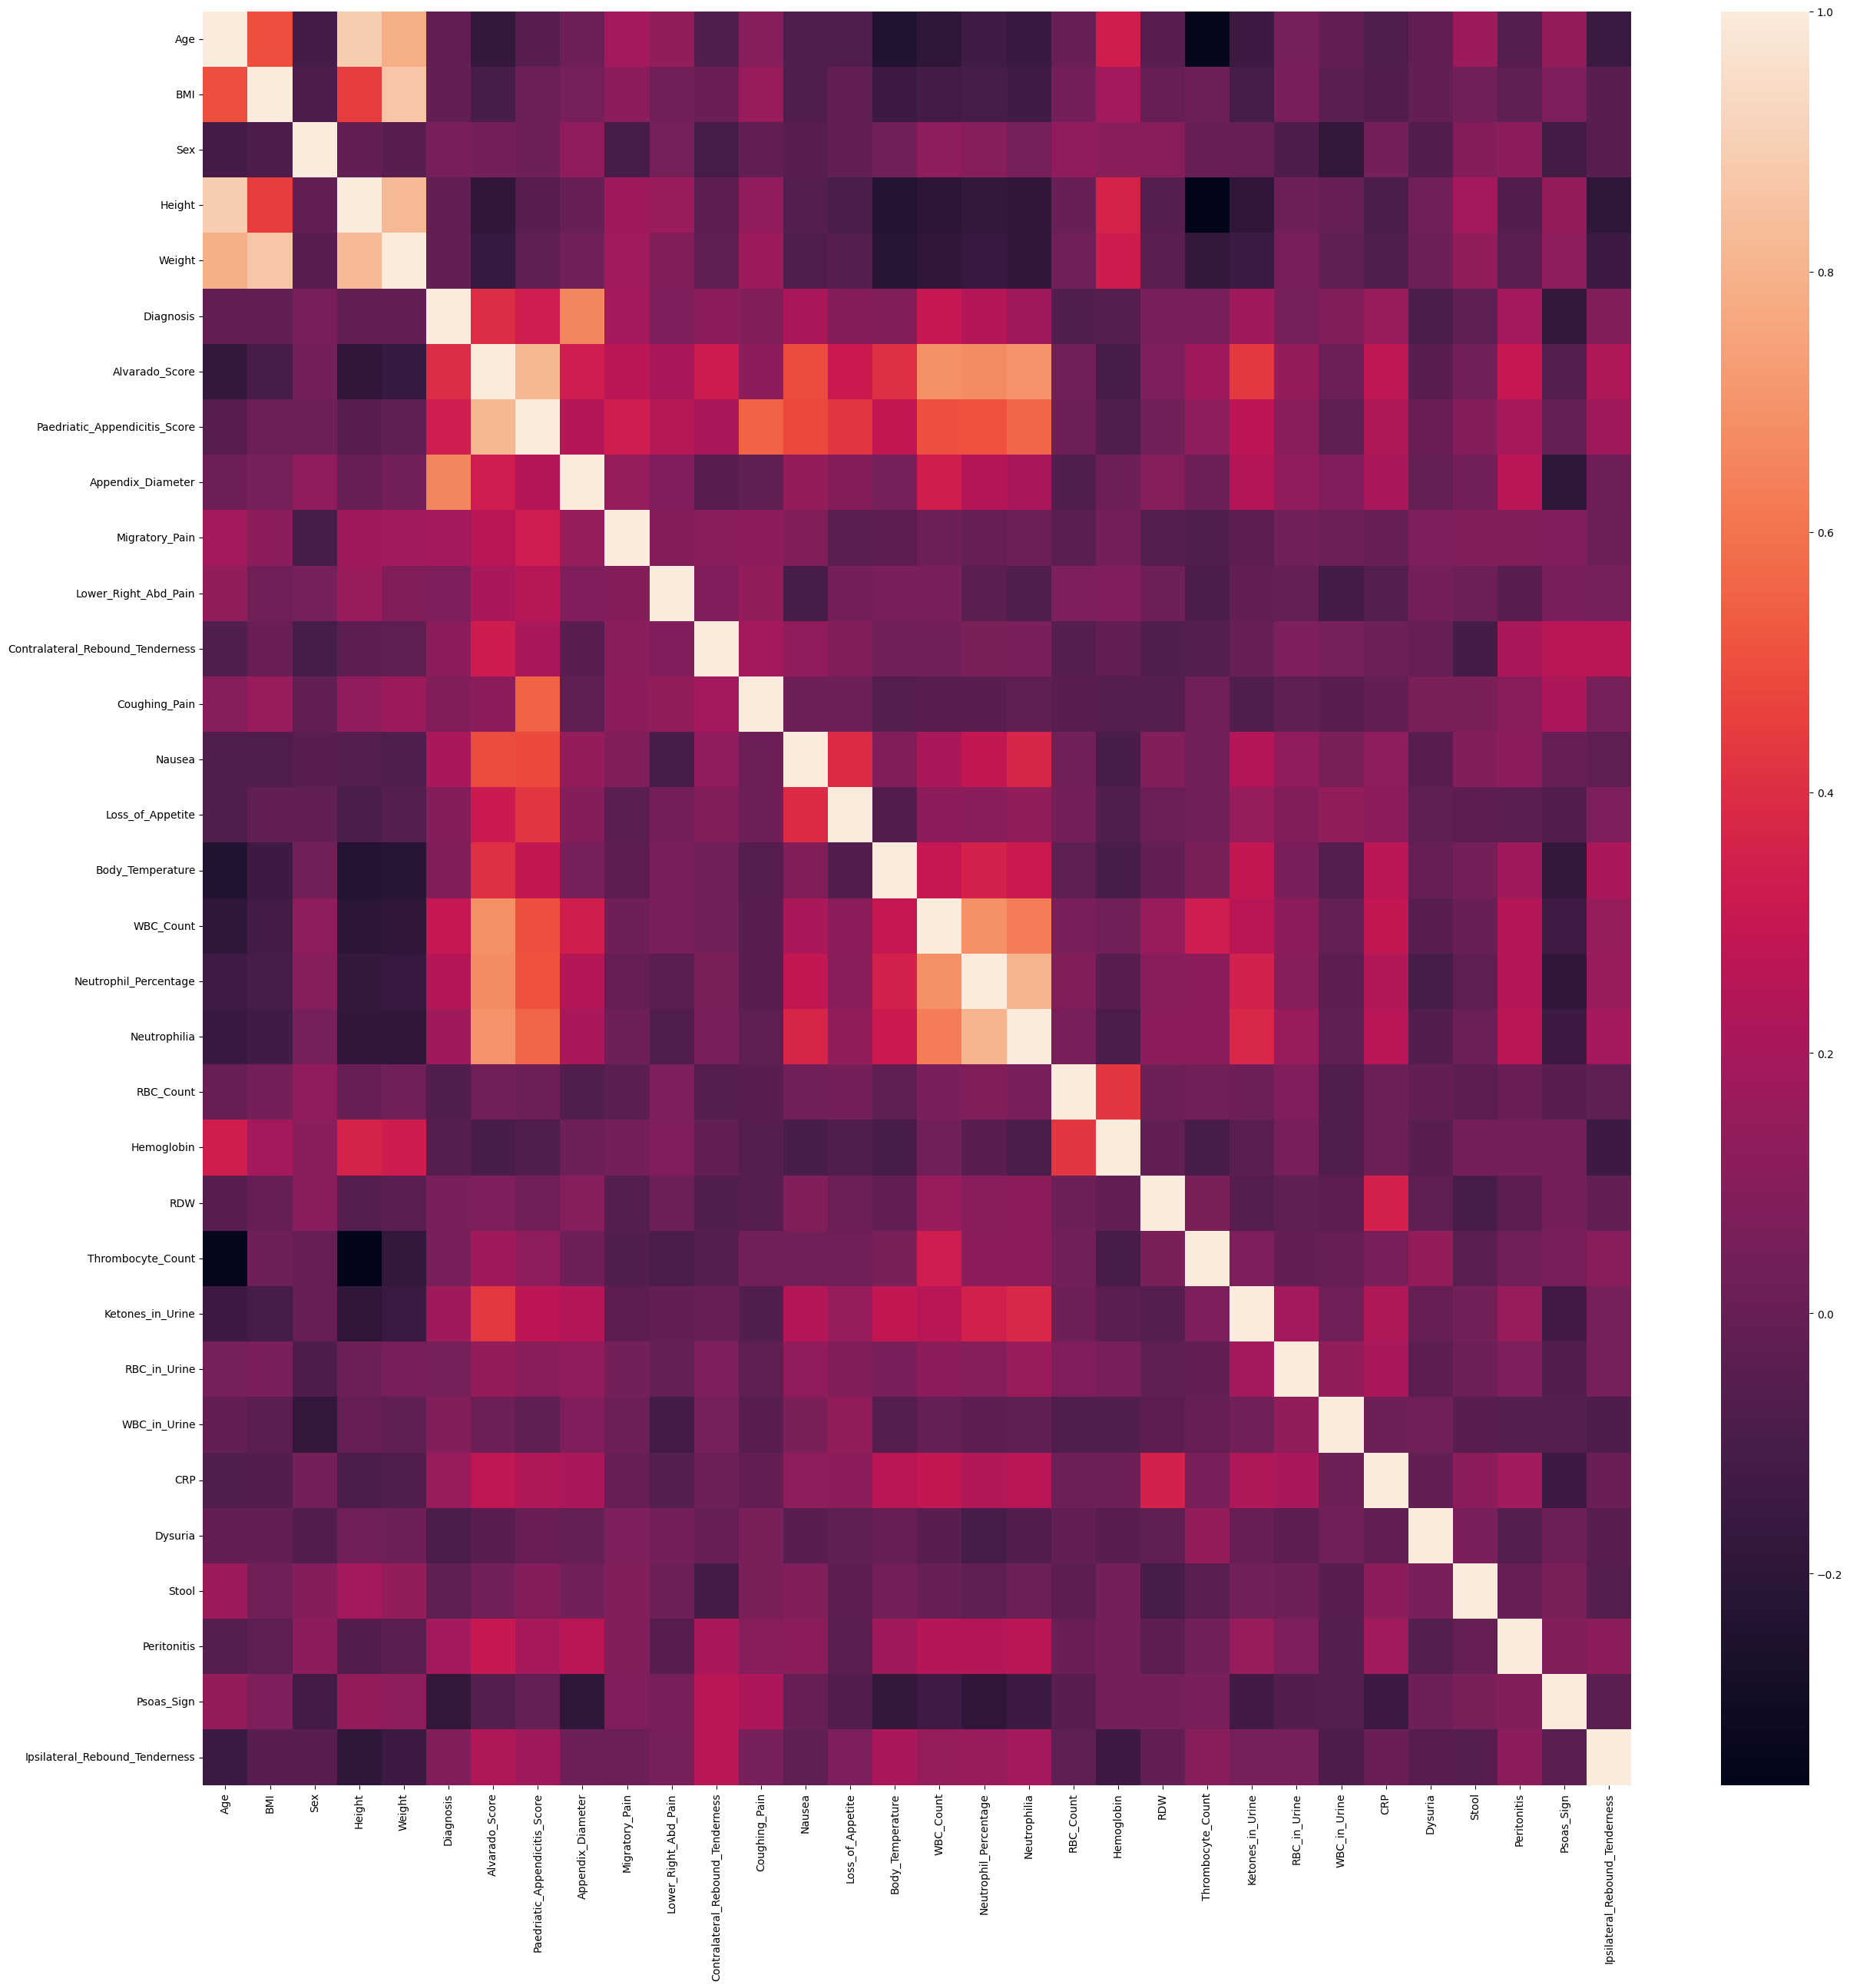

In [66]:
plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())

In [67]:
df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)

In [68]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [69]:
# dsafsf

In [70]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(238, 32)

# APPLYING BORUTA ALGORITHM FOR FEATURE SELECTION

Iteration: 	1 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	2 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	3 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	4 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	5 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	6 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	7 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	8 / 10
Confirmed: 	3
Tentative: 	3
Rejected: 	26
Iteration: 	9 / 10
Confirmed: 	3
Tentative: 	3
Rejected: 	26


BorutaPy finished running.

Iteration: 	10 / 10
Confirmed: 	3
Tentative: 	2
Rejected: 	26

------Support and Ranking for each feature------
Doesn't pass the test:  Age  - Ranking:  17
Doesn't pass the test:  BMI  - Ranking:  7
Doesn't pass the test:  Sex  - Ranking:  25
Doesn't pass the test:  Height  - Ranking:  12
Doesn't pass the test:  Weight  - Ranking:  4
Passes the test:  Alvarado_Score  - Ranking:  1
Passes the test:  Paedriatic_Appendic

Index(['Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_Diameter',
       'WBC_Count', 'Coughing_Pain', 'Thrombocyte_Count', 'Weight', 'CRP',
       'Stool', 'BMI', 'Neutrophil_Percentage', 'RDW', 'RBC_Count',
       'Body_Temperature', 'Hemoglobin', 'Height',
       'Contralateral_Rebound_Tenderness', 'WBC_in_Urine'],
      dtype='object')

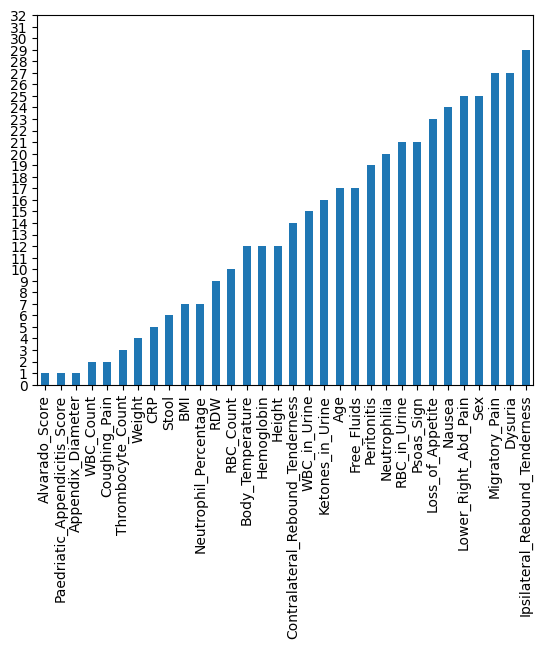

In [71]:
#Applying BORUTA algorithm

# from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import pandas as pd
import numpy as np

# # let's load the load_diabetes() dataset from sklearn
# X, y = load_diabetes(return_X_y=True, as_frame=True)

# let's initialize a RF model 
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
model.fit(x,y)

# let's initialize Boruta
feat_selector = BorutaPy(
    verbose=2,
    estimator=model,
    n_estimators='auto',
    max_iter=10  # number of iterations to perform
   
)

# train Boruta
# N.B.: X and y must be numpy arrays
feat_selector.fit(np.array(x), np.array(y))

# print support and ranking for each feature
print("\n------Support and Ranking for each feature------")
for i in range(len(feat_selector.support_)):
    if feat_selector.support_[i]:
        print("Passes the test: ", x.columns[i],
              " - Ranking: ", feat_selector.ranking_[i])
    else:
        print("Doesn't pass the test: ",
              x.columns[i], " - Ranking: ", feat_selector.ranking_[i])
        
        
        
sel_col = pd.Series(feat_selector.ranking_,index=x.columns)
sel_col.sort_values(inplace=True)



sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly



brt15 = sel_col[sel_col.values<16]
brt15.index

In [72]:
cols = brt15.index

In [73]:
col =list(cols)
col.append("Diagnosis")
df = df.loc[:,col]

In [74]:
col

['Alvarado_Score',
 'Paedriatic_Appendicitis_Score',
 'Appendix_Diameter',
 'WBC_Count',
 'Coughing_Pain',
 'Thrombocyte_Count',
 'Weight',
 'CRP',
 'Stool',
 'BMI',
 'Neutrophil_Percentage',
 'RDW',
 'RBC_Count',
 'Body_Temperature',
 'Hemoglobin',
 'Height',
 'Contralateral_Rebound_Tenderness',
 'WBC_in_Urine',
 'Diagnosis']

In [75]:
df["Diagnosis"].value_counts()

1    463
0    317
Name: Diagnosis, dtype: int64

In [76]:
# df4 = df.dropna()
# aaaaaaaaaa

In [77]:
# df4.shape
df2["Free_Fluids"].value_counts()

0    142
1     96
Name: Free_Fluids, dtype: int64

C:\Users\shadj\AppData\Local\Temp\ipykernel_25088\3065473900.py:18: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 313 entries, 0 to 781
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Alvarado_Score                    313 non-null    float64
 1   Paedriatic_Appendicitis_Score     313 non-null    float64
 2   Appendix_Diameter                 313 non-null    float64
 3   WBC_Count                         313 non-null    float64
 4   Coughing_Pain                     313 non-null    int32  
 5   Thrombocyte_Count                 313 non-null    float64
 6   Weight                            313 non-null    float64
 7   CRP                               313 non-null    float64
 8   Stool                             313 non-null    object 
 9   BMI                               313 non-null    float64
 10  Neutrophil_Percentage             313 non-null    float64
 11  RDW                               313 non-null    float64
 12  RBC_Coun

1    225
0     88
Name: Diagnosis, dtype: int64

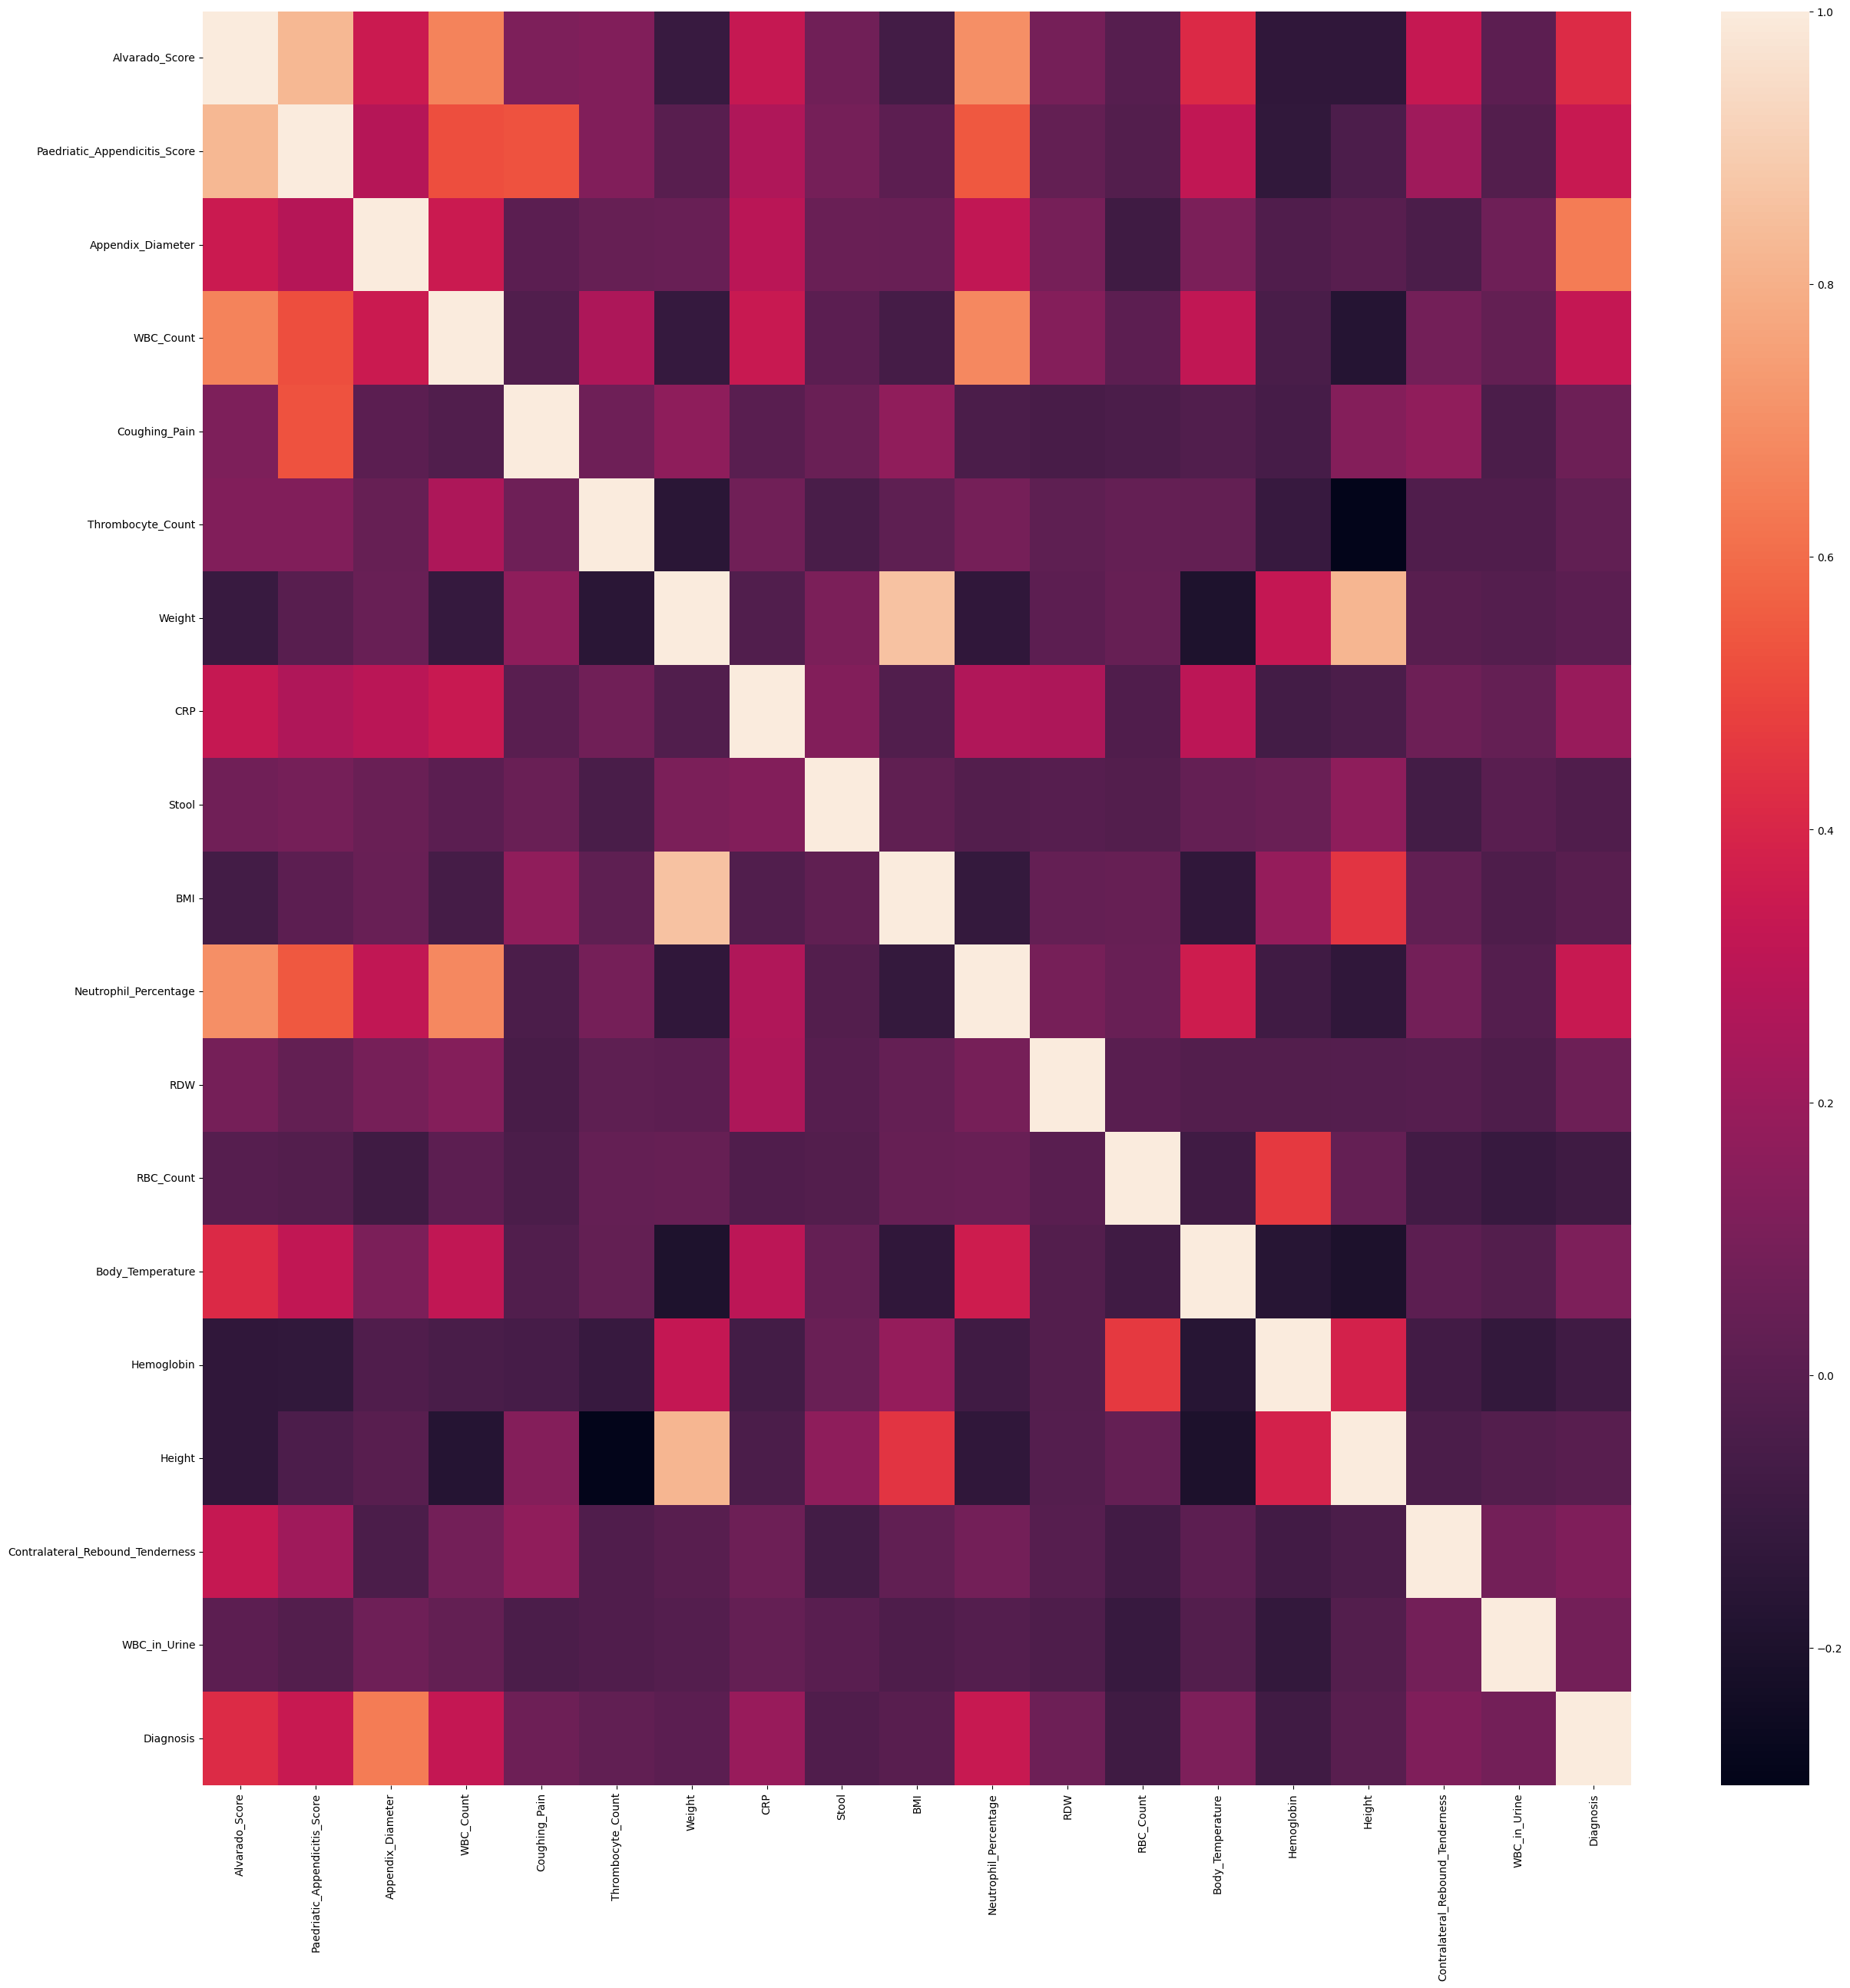

In [83]:
# preprocessing:


# removing the rows whose diagnosis column is nan
# df = df[df['Diagnosis'].notna()]
# df['Diagnosis'].value_counts(dropna = False)


# In[8]:


#converting the diagnosis value to int type
# df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)



# correlation of different columns with each other
df.corr()


# #  correlation of our output column with other columns
# df.corr()['Diagnosis']


# df


# # In[14]:


# #This is the list of other target or output columns
# target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]


# # In[15]:


# # REmoving other target columns since they are not necessary
# df.drop(target_cols,axis=1,inplace =True)


# # In[16]:


# #information of the remaining dataframe
# df.info()


# # In[17]:


# #removing the "Segmented_Neutrophils" Column, Since it had very few values
# df.drop("Segmented_Neutrophils",axis=1,inplace=True)


# # In[18]:


# df.info()


# <h2>Selecting only those rows which have no nan values : </h2>

# In[19]:


df2 = df.dropna().copy()


# In[20]:


df2


# In[21]:


df2.columns


# In[22]:


# df2["WBC_in_Urine"].value_counts()


# In[23]:


# df2["Sex"].value_counts()


# In[24]:


df2["Diagnosis"].value_counts()


# In[25]:


# df.info()


# In[26]:


# df2["Sex"].value_counts()


# In[27]:


# df2["Sex"] = (df["Sex"]=="male").astype(int)


# In[28]:


# df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)


# In[29]:


# df.info()


# In[30]:


# df2["Lower_Right_Abd_Pain"].value_counts()


# In[31]:


# df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
# df2["Lower_Right_Abd_Pain"].value_counts()


# In[32]:


# df2["Contralateral_Rebound_Tenderness"].value_counts()


# In[33]:


df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
# df2['Contralateral_Rebound_Tenderness'].value_counts()


# In[34]:


# df2["Coughing_Pain"].value_counts(dropna = False)


# In[35]:


df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
# df2["Coughing_Pain"].value_counts()


# In[36]:


# df2["Nausea"].value_counts(dropna = False)


# In[37]:


# df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
# df2["Nausea"].value_counts()


# In[38]:


# df2["Loss_of_Appetite"].value_counts(dropna= False)


# In[39]:


# df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
# df2["Loss_of_Appetite"].value_counts()


# In[40]:


# df2["Neutrophilia"].value_counts(dropna = False)


# In[41]:


# df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
# df2["Neutrophilia"].value_counts()


# In[42]:


# df2["Ketones_in_Urine"].value_counts(dropna = False)


# In[43]:


from sklearn.preprocessing import OrdinalEncoder
# enc = OrdinalEncoder(categories=[['no','+','++','+++']])
# enc.fit([['no'], ['+'], ['++'],['+++']])                                 
# df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
# df2["Ketones_in_Urine"].value_counts(dropna = False)


# In[44]:


df2.info()


# In[45]:


# df2["RBC_in_Urine"].value_counts(dropna = False)


# In[46]:


# enc = OrdinalEncoder(categories=[['no','+','++','+++']])
# enc.fit([['no'], ['+'], ['++'],['+++']])                                 
# df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
# df2["RBC_in_Urine"].value_counts(dropna = False)


# In[47]:


# df2["WBC_in_Urine"].value_counts(dropna= False)


# In[48]:


enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
df2["WBC_in_Urine"].value_counts(dropna = False)


# In[49]:


# df2["Dysuria"].value_counts(dropna= False)


# In[50]:


# df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
# df2["Dysuria"].value_counts()


# In[51]:


# df2["Stool"].value_counts()
#will do one hot encoding here


# In[52]:


enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)


# In[53]:


# df2["Peritonitis"] = (df2["Peritonitis"]!='no').astype(int)

# In[58]:


# df2["Diagnosis"].corr(df2["Peritonitis_binary"])


# In[59]:


# df2["Psoas_Sign"].value_counts()


# In[60]:


# df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)


# In[61]:


# df2["Ipsilateral_Rebound_Tenderness"].value_counts()


# In[62]:


# df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)


# In[63]:


df2.info()


# In[64]:


df2.corr()["Diagnosis"]


# In[65]:


plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())


# In[66]:


# df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)


# In[67]:


df2["Diagnosis"].value_counts()


In [84]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(313, 18)

In [85]:
y.value_counts()

1    225
0     88
Name: Diagnosis, dtype: int64

In [86]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 313 entries, 0 to 781
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Alvarado_Score                    313 non-null    float64
 1   Paedriatic_Appendicitis_Score     313 non-null    float64
 2   Appendix_Diameter                 313 non-null    float64
 3   WBC_Count                         313 non-null    float64
 4   Coughing_Pain                     313 non-null    int32  
 5   Thrombocyte_Count                 313 non-null    float64
 6   Weight                            313 non-null    float64
 7   CRP                               313 non-null    float64
 8   Stool                             313 non-null    float64
 9   BMI                               313 non-null    float64
 10  Neutrophil_Percentage             313 non-null    float64
 11  RDW                               313 non-null    float64
 12  RBC_Coun

In [87]:
from sklearn.model_selection import train_test_split

In [88]:
x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [89]:
x_train.shape

(250, 18)

In [90]:
# y_train.value_counts()

In [91]:
# col
x_train.columns

Index(['Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_Diameter',
       'WBC_Count', 'Coughing_Pain', 'Thrombocyte_Count', 'Weight', 'CRP',
       'Stool', 'BMI', 'Neutrophil_Percentage', 'RDW', 'RBC_Count',
       'Body_Temperature', 'Hemoglobin', 'Height',
       'Contralateral_Rebound_Tenderness', 'WBC_in_Urine'],
      dtype='object')

In [92]:
y_test.value_counts()
y_train.value_counts()

1    177
0     73
Name: Diagnosis, dtype: int64

In [93]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.36      0.33      0.34        15
           1       0.80      0.81      0.80        48

    accuracy                           0.70        63
   macro avg       0.58      0.57      0.57        63
weighted avg       0.69      0.70      0.69        63



In [94]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.05 ± 0.00
TEST_ACCURACY - Mean: 0.71 ± 0.06
TEST_F1 - Mean: 0.81 ± 0.04
TEST_ROC_AUC - Mean: 0.67 ± 0.05
TEST_AVERAGE_PRECISION - Mean: 0.81 ± 0.06
TEST_PRECISION - Mean: 0.77 ± 0.06
TEST_RECALL - Mean: 0.86 ± 0.04


In [95]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.2f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.8598
Fold 2: AUPR = 0.7936
Fold 3: AUPR = 0.7957
Fold 4: AUPR = 0.8911
Fold 5: AUPR = 0.8982

Average AUPR: 0.85 +- 0.05


In [96]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.48      0.73      0.58        15
           1       0.90      0.75      0.82        48

    accuracy                           0.75        63
   macro avg       0.69      0.74      0.70        63
weighted avg       0.80      0.75      0.76        63



In [97]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X =x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.03 ± 0.00
TEST_ACCURACY - Mean: 0.77 ± 0.05
TEST_F1 - Mean: 0.82 ± 0.05
TEST_ROC_AUC - Mean: 0.88 ± 0.05
TEST_AVERAGE_PRECISION - Mean: 0.94 ± 0.04
TEST_PRECISION - Mean: 0.92 ± 0.05
TEST_RECALL - Mean: 0.74 ± 0.06


In [98]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.2f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9518
Fold 2: AUPR = 0.8599
Fold 3: AUPR = 0.9259
Fold 4: AUPR = 0.9627
Fold 5: AUPR = 0.9886

Average AUPR: 0.94 +- 0.04


In [99]:
from sklearn.svm import SVC
model = SVC()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.76      1.00      0.86        48

    accuracy                           0.76        63
   macro avg       0.38      0.50      0.43        63
weighted avg       0.58      0.76      0.66        63



C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [100]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X =x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.03 ± 0.01
TEST_ACCURACY - Mean: 0.72 ± 0.04
TEST_F1 - Mean: 0.84 ± 0.03
TEST_ROC_AUC - Mean: 0.81 ± 0.02
TEST_AVERAGE_PRECISION - Mean: 0.92 ± 0.02
TEST_PRECISION - Mean: 0.72 ± 0.04
TEST_RECALL - Mean: 1.00 ± 0.00


In [101]:
# This will not work here

# from sklearn.metrics import precision_recall_curve,auc
# def calc_aupr():
#     # Initialize list to store AUPR values for each fold
#     aupr_list = []
 
#     X = x
#     # Perform 5-fold cross-validation
#     for train_index, test_index in kf.split(X):
#         X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#         y_train, y_test = y.iloc[train_index], y.iloc[test_index]

#         # Train the model
#         model.fit(X_train, y_train)

#         # Predict probabilities on the validation set
#         y_proba = model.predict_proba(X_test)

#         # Compute precision and recall
#         precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

#         # Compute AUPR for the current fold
#         aupr = auc(recall, precision)

#         # Append AUPR to the list
#         aupr_list.append(aupr)

#     # Print AUPR values for each fold
#     for fold, aupr in enumerate(aupr_list, start=1):
#         print(f"Fold {fold}: AUPR = {aupr:.4f}")

#     # Calculate and print average AUPR over all folds
#     avg_aupr = np.mean(aupr_list)
#     std_aupr = np.std(aupr_list)
#     print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

# calc_aupr()

In [102]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        15
           1       0.94      0.96      0.95        48

    accuracy                           0.92        63
   macro avg       0.90      0.88      0.89        63
weighted avg       0.92      0.92      0.92        63



In [103]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.03 ± 0.01
TEST_ACCURACY - Mean: 0.95 ± 0.01
TEST_F1 - Mean: 0.96 ± 0.01
TEST_ROC_AUC - Mean: 0.93 ± 0.02
TEST_AVERAGE_PRECISION - Mean: 0.95 ± 0.02
TEST_PRECISION - Mean: 0.96 ± 0.03
TEST_RECALL - Mean: 0.97 ± 0.02


In [104]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9644
Fold 2: AUPR = 0.9674
Fold 3: AUPR = 0.9609
Fold 4: AUPR = 0.9802
Fold 5: AUPR = 0.9812

Average AUPR: 0.9708 +- 0.01


In [105]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       0.94      1.00      0.97        45

    accuracy                           0.95        63
   macro avg       0.97      0.92      0.94        63
weighted avg       0.96      0.95      0.95        63



In [106]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate
# x_train = pd.DataFrame(x_train)
# x_test = pd.DataFrame(x_test)
# y_train = pd.DataFrame(y_train)
# y_test = pd.DataFrame(y_test)
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.44 ± 0.02
SCORE_TIME - Mean: 0.05 ± 0.00
TEST_ACCURACY - Mean: 0.94 ± 0.03
TEST_F1 - Mean: 0.96 ± 0.02
TEST_ROC_AUC - Mean: 0.98 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01


In [107]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9996
Fold 2: AUPR = 0.9875
Fold 3: AUPR = 0.9893
Fold 4: AUPR = 0.9907
Fold 5: AUPR = 0.9982

Average AUPR: 0.9931 +- 0.00


In [108]:
from xgboost import XGBClassifier
# from catboost import CatBoostClassifier
model = XGBClassifier(iterations=1500,learning_rate=0.1,depth=6,loss_function='Logloss')
model.fit(x_train,y_train,verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.93      0.87        15
           1       0.98      0.94      0.96        48

    accuracy                           0.94        63
   macro avg       0.90      0.94      0.92        63
weighted avg       0.94      0.94      0.94        63



C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [15:13:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)


In [109]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x
# y= pd.concat([y_train,y_test])

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [15:13:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [15:13:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [15:13:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.



FIT_TIME - Mean: 0.12 ± 0.00
SCORE_TIME - Mean: 0.04 ± 0.00
TEST_ACCURACY - Mean: 0.94 ± 0.02
TEST_F1 - Mean: 0.96 ± 0.02
TEST_ROC_AUC - Mean: 0.99 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 1.00 ± 0.00
TEST_PRECISION - Mean: 0.98 ± 0.02
TEST_RECALL - Mean: 0.94 ± 0.03


In [110]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [15:13:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [15:13:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [15:13:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.



Fold 1: AUPR = 0.9952
Fold 2: AUPR = 1.0000
Fold 3: AUPR = 0.9891
Fold 4: AUPR = 0.9916
Fold 5: AUPR = 0.9991

Average AUPR: 0.9950 +- 0.00


C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [15:13:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)


In [111]:
from lightgbm import LGBMClassifier
model = LGBMClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.87      0.90        15
           1       0.96      0.98      0.97        48

    accuracy                           0.95        63
   macro avg       0.94      0.92      0.93        63
weighted avg       0.95      0.95      0.95        63



In [112]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.07 ± 0.01
SCORE_TIME - Mean: 0.03 ± 0.00
TEST_ACCURACY - Mean: 0.95 ± 0.02
TEST_F1 - Mean: 0.96 ± 0.02
TEST_ROC_AUC - Mean: 0.98 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.00
TEST_PRECISION - Mean: 0.96 ± 0.02
TEST_RECALL - Mean: 0.96 ± 0.03


In [113]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9926 ± 0.00


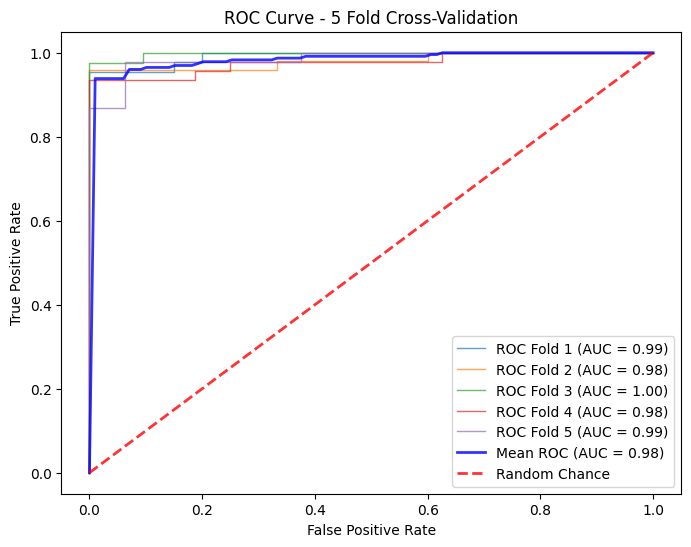

In [114]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
# X = x
X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [115]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.87      0.93        15
           1       0.96      1.00      0.98        48

    accuracy                           0.97        63
   macro avg       0.98      0.93      0.95        63
weighted avg       0.97      0.97      0.97        63



In [116]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.29 ± 0.02
SCORE_TIME - Mean: 0.07 ± 0.00
TEST_ACCURACY - Mean: 0.62 ± 0.05
TEST_F1 - Mean: 0.75 ± 0.03
TEST_ROC_AUC - Mean: 0.52 ± 0.04
TEST_AVERAGE_PRECISION - Mean: 0.74 ± 0.04
TEST_PRECISION - Mean: 0.71 ± 0.06
TEST_RECALL - Mean: 0.80 ± 0.02


In [117]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.7441 ± 0.04


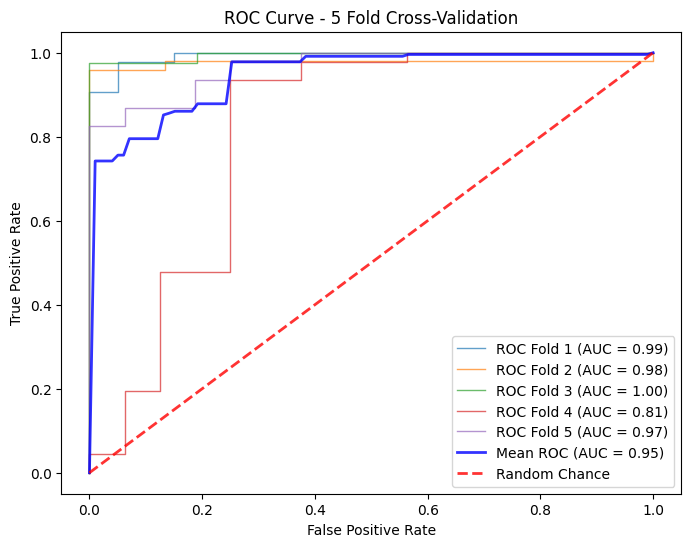

In [118]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
# X = x
X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [119]:
from catboost import CatBoostClassifier
model =  CatBoostClassifier(iterations=1500, learning_rate=0.01, depth=5, loss_function='Logloss')
model.fit(x_train,y_train, eval_set= (x_test,y_test), verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90        16
           1       0.96      0.98      0.97        47

    accuracy                           0.95        63
   macro avg       0.95      0.93      0.94        63
weighted avg       0.95      0.95      0.95        63



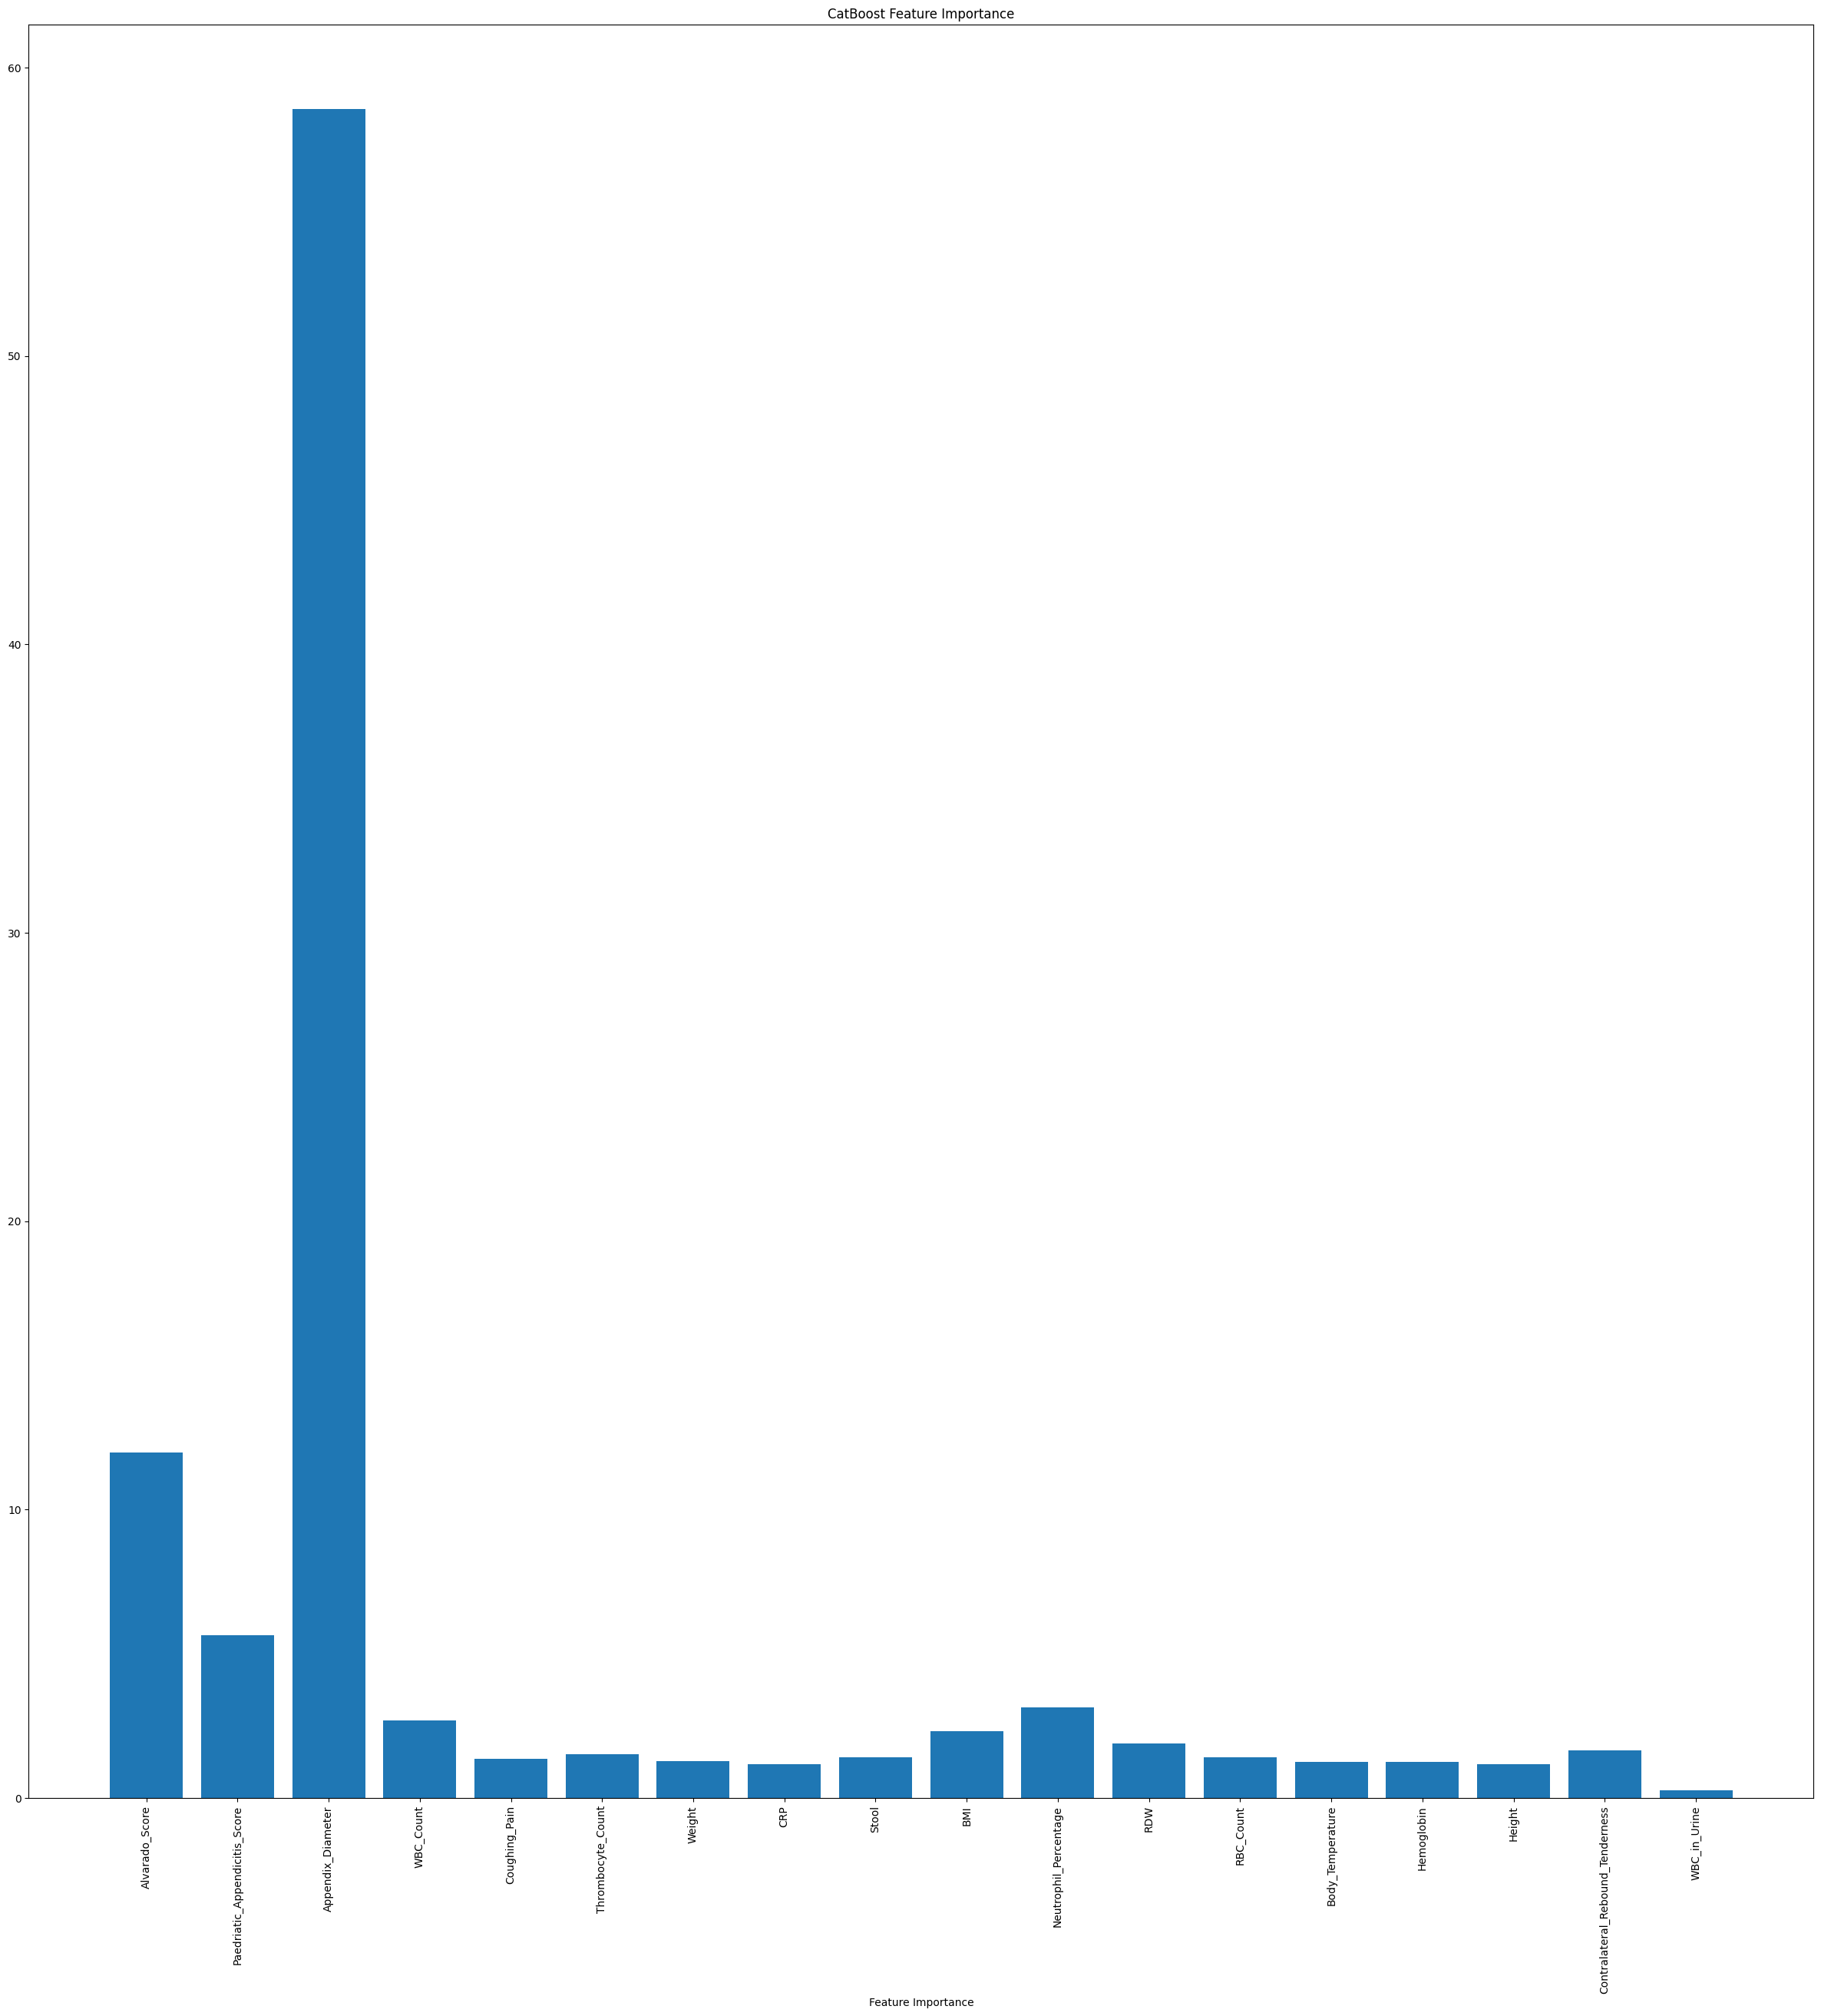

In [120]:
import matplotlib.pyplot as plt    
feature_importance = model.get_feature_importance()
feature_names = X.columns 
plt.figure(figsize=(30,30))
plt.bar(feature_names, feature_importance) 
plt.xlabel("Feature Importance") 
plt.title("CatBoost Feature Importance")
plt.xticks(rotation=90)
plt.show()

In [121]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

0:	learn: 0.6899547	total: 5.51ms	remaining: 8.26s
1:	learn: 0.6860508	total: 11.3ms	remaining: 8.5s
2:	learn: 0.6823981	total: 16.8ms	remaining: 8.37s
3:	learn: 0.6786001	total: 21.7ms	remaining: 8.12s
4:	learn: 0.6751018	total: 26.9ms	remaining: 8.05s
5:	learn: 0.6728470	total: 31.6ms	remaining: 7.86s
6:	learn: 0.6696590	total: 36.9ms	remaining: 7.86s
7:	learn: 0.6666361	total: 42.1ms	remaining: 7.85s
8:	learn: 0.6642219	total: 47.8ms	remaining: 7.92s
9:	learn: 0.6619391	total: 53ms	remaining: 7.9s
10:	learn: 0.6590586	total: 60ms	remaining: 8.13s
11:	learn: 0.6556404	total: 65.9ms	remaining: 8.18s
12:	learn: 0.6529615	total: 71.3ms	remaining: 8.16s
13:	learn: 0.6498156	total: 76.7ms	remaining: 8.14s
14:	learn: 0.6477673	total: 81.9ms	remaining: 8.11s
15:	learn: 0.6449664	total: 87.5ms	remaining: 8.12s
16:	learn: 0.6425966	total: 92.9ms	remaining: 8.11s
17:	learn: 0.6395478	total: 98.9ms	remaining: 8.14s
18:	learn: 0.6367584	total: 105ms	remaining: 8.18s
19:	learn: 0.6342939	total: 1

176:	learn: 0.4323961	total: 988ms	remaining: 7.38s
177:	learn: 0.4319698	total: 994ms	remaining: 7.38s
178:	learn: 0.4309249	total: 1s	remaining: 7.38s
179:	learn: 0.4304290	total: 1s	remaining: 7.38s
180:	learn: 0.4298388	total: 1.01s	remaining: 7.37s
181:	learn: 0.4289364	total: 1.02s	remaining: 7.36s
182:	learn: 0.4279521	total: 1.02s	remaining: 7.36s
183:	learn: 0.4276651	total: 1.03s	remaining: 7.34s
184:	learn: 0.4270704	total: 1.03s	remaining: 7.34s
185:	learn: 0.4265368	total: 1.04s	remaining: 7.33s
186:	learn: 0.4254626	total: 1.04s	remaining: 7.33s
187:	learn: 0.4246254	total: 1.05s	remaining: 7.33s
188:	learn: 0.4239941	total: 1.05s	remaining: 7.32s
189:	learn: 0.4229104	total: 1.06s	remaining: 7.32s
190:	learn: 0.4223183	total: 1.07s	remaining: 7.31s
191:	learn: 0.4215235	total: 1.07s	remaining: 7.31s
192:	learn: 0.4206043	total: 1.08s	remaining: 7.3s
193:	learn: 0.4200667	total: 1.08s	remaining: 7.3s
194:	learn: 0.4194261	total: 1.09s	remaining: 7.3s
195:	learn: 0.4188838

347:	learn: 0.3349556	total: 1.97s	remaining: 6.53s
348:	learn: 0.3345664	total: 1.98s	remaining: 6.53s
349:	learn: 0.3337945	total: 1.98s	remaining: 6.52s
350:	learn: 0.3335754	total: 1.99s	remaining: 6.51s
351:	learn: 0.3332035	total: 1.99s	remaining: 6.5s
352:	learn: 0.3327612	total: 2s	remaining: 6.5s
353:	learn: 0.3321526	total: 2s	remaining: 6.49s
354:	learn: 0.3317155	total: 2.01s	remaining: 6.49s
355:	learn: 0.3311906	total: 2.02s	remaining: 6.48s
356:	learn: 0.3309562	total: 2.02s	remaining: 6.48s
357:	learn: 0.3304943	total: 2.03s	remaining: 6.47s
358:	learn: 0.3299671	total: 2.03s	remaining: 6.46s
359:	learn: 0.3295662	total: 2.04s	remaining: 6.46s
360:	learn: 0.3289276	total: 2.04s	remaining: 6.45s
361:	learn: 0.3284566	total: 2.05s	remaining: 6.44s
362:	learn: 0.3282856	total: 2.05s	remaining: 6.43s
363:	learn: 0.3279672	total: 2.06s	remaining: 6.43s
364:	learn: 0.3274867	total: 2.06s	remaining: 6.42s
365:	learn: 0.3267493	total: 2.07s	remaining: 6.42s
366:	learn: 0.326502

510:	learn: 0.2684025	total: 2.74s	remaining: 5.31s
511:	learn: 0.2681812	total: 2.75s	remaining: 5.31s
512:	learn: 0.2677015	total: 2.75s	remaining: 5.3s
513:	learn: 0.2672286	total: 2.76s	remaining: 5.29s
514:	learn: 0.2666033	total: 2.77s	remaining: 5.29s
515:	learn: 0.2663258	total: 2.77s	remaining: 5.28s
516:	learn: 0.2659750	total: 2.77s	remaining: 5.28s
517:	learn: 0.2656157	total: 2.78s	remaining: 5.27s
518:	learn: 0.2652524	total: 2.79s	remaining: 5.26s
519:	learn: 0.2649821	total: 2.79s	remaining: 5.26s
520:	learn: 0.2647035	total: 2.79s	remaining: 5.25s
521:	learn: 0.2644193	total: 2.8s	remaining: 5.24s
522:	learn: 0.2638687	total: 2.81s	remaining: 5.24s
523:	learn: 0.2635559	total: 2.81s	remaining: 5.23s
524:	learn: 0.2633225	total: 2.81s	remaining: 5.23s
525:	learn: 0.2630583	total: 2.82s	remaining: 5.22s
526:	learn: 0.2624717	total: 2.83s	remaining: 5.22s
527:	learn: 0.2620839	total: 2.83s	remaining: 5.21s
528:	learn: 0.2617249	total: 2.83s	remaining: 5.2s
529:	learn: 0.2

690:	learn: 0.2046003	total: 3.71s	remaining: 4.35s
691:	learn: 0.2044271	total: 3.72s	remaining: 4.34s
692:	learn: 0.2042044	total: 3.73s	remaining: 4.34s
693:	learn: 0.2041058	total: 3.73s	remaining: 4.34s
694:	learn: 0.2038462	total: 3.74s	remaining: 4.33s
695:	learn: 0.2035400	total: 3.74s	remaining: 4.33s
696:	learn: 0.2030485	total: 3.75s	remaining: 4.32s
697:	learn: 0.2027843	total: 3.75s	remaining: 4.31s
698:	learn: 0.2022784	total: 3.76s	remaining: 4.31s
699:	learn: 0.2018249	total: 3.77s	remaining: 4.3s
700:	learn: 0.2012599	total: 3.77s	remaining: 4.3s
701:	learn: 0.2011129	total: 3.77s	remaining: 4.29s
702:	learn: 0.2009339	total: 3.78s	remaining: 4.29s
703:	learn: 0.2005066	total: 3.79s	remaining: 4.28s
704:	learn: 0.2001424	total: 3.79s	remaining: 4.27s
705:	learn: 0.1997208	total: 3.79s	remaining: 4.27s
706:	learn: 0.1994567	total: 3.8s	remaining: 4.26s
707:	learn: 0.1992624	total: 3.81s	remaining: 4.26s
708:	learn: 0.1990213	total: 3.81s	remaining: 4.25s
709:	learn: 0.1

...

743:	learn: 0.2143469	total: 4.08s	remaining: 4.15s
744:	learn: 0.2138437	total: 4.09s	remaining: 4.14s
745:	learn: 0.2136282	total: 4.09s	remaining: 4.14s
746:	learn: 0.2135810	total: 4.1s	remaining: 4.13s
747:	learn: 0.2130476	total: 4.11s	remaining: 4.13s
748:	learn: 0.2128405	total: 4.11s	remaining: 4.12s
749:	learn: 0.2122000	total: 4.11s	remaining: 4.11s
750:	learn: 0.2119056	total: 4.12s	remaining: 4.11s
751:	learn: 0.2118478	total: 4.12s	remaining: 4.1s
752:	learn: 0.2114402	total: 4.13s	remaining: 4.09s
753:	learn: 0.2110808	total: 4.13s	remaining: 4.09s
754:	learn: 0.2110308	total: 4.14s	remaining: 4.08s
755:	learn: 0.2105668	total: 4.14s	remaining: 4.08s
756:	learn: 0.2100885	total: 4.15s	remaining: 4.07s
757:	learn: 0.2098843	total: 4.15s	remaining: 4.07s
758:	learn: 0.2093154	total: 4.16s	remaining: 4.06s
759:	learn: 0.2092236	total: 4.17s	remaining: 4.06s
760:	learn: 0.2089987	total: 4.17s	remaining: 4.05s
761:	learn: 0.2087154	total: 4.18s	remaining: 4.05s
762:	learn: 0.

922:	learn: 0.1643886	total: 5.07s	remaining: 3.17s
923:	learn: 0.1640587	total: 5.08s	remaining: 3.16s
924:	learn: 0.1636629	total: 5.08s	remaining: 3.16s
925:	learn: 0.1632185	total: 5.09s	remaining: 3.15s
926:	learn: 0.1630031	total: 5.09s	remaining: 3.15s
927:	learn: 0.1627546	total: 5.1s	remaining: 3.14s
928:	learn: 0.1625795	total: 5.11s	remaining: 3.14s
929:	learn: 0.1623081	total: 5.11s	remaining: 3.13s
930:	learn: 0.1619420	total: 5.13s	remaining: 3.13s
931:	learn: 0.1617117	total: 5.13s	remaining: 3.13s
932:	learn: 0.1616954	total: 5.14s	remaining: 3.12s
933:	learn: 0.1614865	total: 5.14s	remaining: 3.12s
934:	learn: 0.1611714	total: 5.15s	remaining: 3.11s
935:	learn: 0.1608573	total: 5.16s	remaining: 3.11s
936:	learn: 0.1608330	total: 5.16s	remaining: 3.1s
937:	learn: 0.1604402	total: 5.17s	remaining: 3.1s
938:	learn: 0.1601116	total: 5.17s	remaining: 3.09s
939:	learn: 0.1597314	total: 5.18s	remaining: 3.09s
940:	learn: 0.1594110	total: 5.19s	remaining: 3.08s
941:	learn: 0.1

1111:	learn: 0.1244763	total: 6.06s	remaining: 2.12s
1112:	learn: 0.1243180	total: 6.07s	remaining: 2.11s
1113:	learn: 0.1242088	total: 6.07s	remaining: 2.1s
1114:	learn: 0.1241162	total: 6.08s	remaining: 2.1s
1115:	learn: 0.1240952	total: 6.09s	remaining: 2.09s
1116:	learn: 0.1239229	total: 6.09s	remaining: 2.09s
1117:	learn: 0.1239044	total: 6.1s	remaining: 2.08s
1118:	learn: 0.1237441	total: 6.1s	remaining: 2.08s
1119:	learn: 0.1236182	total: 6.11s	remaining: 2.07s
1120:	learn: 0.1234354	total: 6.11s	remaining: 2.06s
1121:	learn: 0.1232924	total: 6.12s	remaining: 2.06s
1122:	learn: 0.1232732	total: 6.12s	remaining: 2.06s
1123:	learn: 0.1231302	total: 6.13s	remaining: 2.05s
1124:	learn: 0.1231149	total: 6.13s	remaining: 2.04s
1125:	learn: 0.1228974	total: 6.14s	remaining: 2.04s
1126:	learn: 0.1226935	total: 6.15s	remaining: 2.03s
1127:	learn: 0.1224634	total: 6.15s	remaining: 2.03s
1128:	learn: 0.1222936	total: 6.16s	remaining: 2.02s
1129:	learn: 0.1221323	total: 6.16s	remaining: 2.0

1295:	learn: 0.0993717	total: 7.01s	remaining: 1.1s
1296:	learn: 0.0993581	total: 7.02s	remaining: 1.1s
1297:	learn: 0.0991166	total: 7.03s	remaining: 1.09s
1298:	learn: 0.0989714	total: 7.03s	remaining: 1.09s
1299:	learn: 0.0986817	total: 7.04s	remaining: 1.08s
1300:	learn: 0.0985387	total: 7.04s	remaining: 1.08s
1301:	learn: 0.0984666	total: 7.05s	remaining: 1.07s
1302:	learn: 0.0983095	total: 7.05s	remaining: 1.07s
1303:	learn: 0.0981659	total: 7.06s	remaining: 1.06s
1304:	learn: 0.0980752	total: 7.06s	remaining: 1.05s
1305:	learn: 0.0979633	total: 7.07s	remaining: 1.05s
1306:	learn: 0.0978498	total: 7.07s	remaining: 1.04s
1307:	learn: 0.0977124	total: 7.08s	remaining: 1.04s
1308:	learn: 0.0976975	total: 7.09s	remaining: 1.03s
1309:	learn: 0.0976176	total: 7.09s	remaining: 1.03s
1310:	learn: 0.0974843	total: 7.1s	remaining: 1.02s
1311:	learn: 0.0973268	total: 7.1s	remaining: 1.02s
1312:	learn: 0.0971056	total: 7.11s	remaining: 1.01s
1313:	learn: 0.0969347	total: 7.11s	remaining: 1.0

1479:	learn: 0.0795404	total: 7.97s	remaining: 108ms
1480:	learn: 0.0794403	total: 7.98s	remaining: 102ms
1481:	learn: 0.0792814	total: 7.98s	remaining: 96.9ms
1482:	learn: 0.0792745	total: 7.99s	remaining: 91.6ms
1483:	learn: 0.0792193	total: 7.99s	remaining: 86.2ms
1484:	learn: 0.0791590	total: 8s	remaining: 80.8ms
1485:	learn: 0.0791459	total: 8s	remaining: 75.4ms
1486:	learn: 0.0790702	total: 8.01s	remaining: 70ms
1487:	learn: 0.0790620	total: 8.01s	remaining: 64.6ms
1488:	learn: 0.0789464	total: 8.02s	remaining: 59.2ms
1489:	learn: 0.0788382	total: 8.02s	remaining: 53.8ms
1490:	learn: 0.0788293	total: 8.03s	remaining: 48.5ms
1491:	learn: 0.0788178	total: 8.03s	remaining: 43.1ms
1492:	learn: 0.0788115	total: 8.04s	remaining: 37.7ms
1493:	learn: 0.0787135	total: 8.05s	remaining: 32.3ms
1494:	learn: 0.0785507	total: 8.05s	remaining: 26.9ms
1495:	learn: 0.0784906	total: 8.05s	remaining: 21.5ms
1496:	learn: 0.0784836	total: 8.06s	remaining: 16.2ms
1497:	learn: 0.0782978	total: 8.07s	re

In [122]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

0:	learn: 0.6899547	total: 6.67ms	remaining: 10s
1:	learn: 0.6860508	total: 14.1ms	remaining: 10.6s
2:	learn: 0.6823981	total: 23.1ms	remaining: 11.5s
3:	learn: 0.6786001	total: 28.9ms	remaining: 10.8s
4:	learn: 0.6751018	total: 34.5ms	remaining: 10.3s
5:	learn: 0.6728470	total: 40.3ms	remaining: 10s
6:	learn: 0.6696590	total: 46.3ms	remaining: 9.87s
7:	learn: 0.6666361	total: 51.7ms	remaining: 9.65s
8:	learn: 0.6642219	total: 57.7ms	remaining: 9.56s
9:	learn: 0.6619391	total: 63.6ms	remaining: 9.48s
10:	learn: 0.6590586	total: 69ms	remaining: 9.35s
11:	learn: 0.6556404	total: 74.7ms	remaining: 9.27s
12:	learn: 0.6529615	total: 80.2ms	remaining: 9.18s
13:	learn: 0.6498156	total: 86.4ms	remaining: 9.17s
14:	learn: 0.6477673	total: 92.6ms	remaining: 9.17s
15:	learn: 0.6449664	total: 99ms	remaining: 9.18s
16:	learn: 0.6425966	total: 106ms	remaining: 9.24s
17:	learn: 0.6395478	total: 112ms	remaining: 9.19s
18:	learn: 0.6367584	total: 118ms	remaining: 9.17s
19:	learn: 0.6342939	total: 123ms

173:	learn: 0.4345388	total: 992ms	remaining: 7.56s
174:	learn: 0.4338609	total: 999ms	remaining: 7.56s
175:	learn: 0.4331049	total: 1s	remaining: 7.55s
176:	learn: 0.4323961	total: 1.01s	remaining: 7.57s
177:	learn: 0.4319698	total: 1.02s	remaining: 7.56s
178:	learn: 0.4309249	total: 1.02s	remaining: 7.56s
179:	learn: 0.4304290	total: 1.03s	remaining: 7.55s
180:	learn: 0.4298388	total: 1.03s	remaining: 7.54s
181:	learn: 0.4289364	total: 1.04s	remaining: 7.55s
182:	learn: 0.4279521	total: 1.05s	remaining: 7.54s
183:	learn: 0.4276651	total: 1.05s	remaining: 7.54s
184:	learn: 0.4270704	total: 1.06s	remaining: 7.53s
185:	learn: 0.4265368	total: 1.06s	remaining: 7.52s
186:	learn: 0.4254626	total: 1.07s	remaining: 7.53s
187:	learn: 0.4246254	total: 1.08s	remaining: 7.53s
188:	learn: 0.4239941	total: 1.08s	remaining: 7.51s
189:	learn: 0.4229104	total: 1.09s	remaining: 7.51s
190:	learn: 0.4223183	total: 1.09s	remaining: 7.49s
191:	learn: 0.4215235	total: 1.1s	remaining: 7.49s
192:	learn: 0.42

336:	learn: 0.3406520	total: 1.97s	remaining: 6.82s
337:	learn: 0.3400653	total: 1.98s	remaining: 6.81s
338:	learn: 0.3392060	total: 1.99s	remaining: 6.81s
339:	learn: 0.3388896	total: 1.99s	remaining: 6.8s
340:	learn: 0.3381568	total: 2s	remaining: 6.79s
341:	learn: 0.3377416	total: 2s	remaining: 6.79s
342:	learn: 0.3370935	total: 2.01s	remaining: 6.78s
343:	learn: 0.3365233	total: 2.02s	remaining: 6.78s
344:	learn: 0.3358403	total: 2.02s	remaining: 6.77s
345:	learn: 0.3355314	total: 2.03s	remaining: 6.76s
346:	learn: 0.3353181	total: 2.03s	remaining: 6.76s
347:	learn: 0.3349556	total: 2.04s	remaining: 6.76s
348:	learn: 0.3345664	total: 2.05s	remaining: 6.76s
349:	learn: 0.3337945	total: 2.05s	remaining: 6.75s
350:	learn: 0.3335754	total: 2.06s	remaining: 6.74s
351:	learn: 0.3332035	total: 2.07s	remaining: 6.74s
352:	learn: 0.3327612	total: 2.07s	remaining: 6.73s
353:	learn: 0.3321526	total: 2.08s	remaining: 6.73s
354:	learn: 0.3317155	total: 2.08s	remaining: 6.72s
355:	learn: 0.33119

507:	learn: 0.2694651	total: 2.98s	remaining: 5.82s
508:	learn: 0.2692180	total: 2.98s	remaining: 5.81s
509:	learn: 0.2687112	total: 2.99s	remaining: 5.8s
510:	learn: 0.2684025	total: 3s	remaining: 5.8s
511:	learn: 0.2681812	total: 3s	remaining: 5.79s
512:	learn: 0.2677015	total: 3.01s	remaining: 5.78s
513:	learn: 0.2672286	total: 3.01s	remaining: 5.78s
514:	learn: 0.2666033	total: 3.02s	remaining: 5.77s
515:	learn: 0.2663258	total: 3.02s	remaining: 5.76s
516:	learn: 0.2659750	total: 3.03s	remaining: 5.76s
517:	learn: 0.2656157	total: 3.03s	remaining: 5.75s
518:	learn: 0.2652524	total: 3.04s	remaining: 5.75s
519:	learn: 0.2649821	total: 3.05s	remaining: 5.74s
520:	learn: 0.2647035	total: 3.05s	remaining: 5.74s
521:	learn: 0.2644193	total: 3.06s	remaining: 5.73s
522:	learn: 0.2638687	total: 3.06s	remaining: 5.72s
523:	learn: 0.2635559	total: 3.07s	remaining: 5.72s
524:	learn: 0.2633225	total: 3.08s	remaining: 5.71s
525:	learn: 0.2630583	total: 3.08s	remaining: 5.7s
526:	learn: 0.2624717

676:	learn: 0.2097163	total: 3.96s	remaining: 4.82s
677:	learn: 0.2094848	total: 3.97s	remaining: 4.81s
678:	learn: 0.2093737	total: 3.97s	remaining: 4.8s
679:	learn: 0.2089332	total: 3.98s	remaining: 4.8s
680:	learn: 0.2085221	total: 3.99s	remaining: 4.79s
681:	learn: 0.2081563	total: 3.99s	remaining: 4.79s
682:	learn: 0.2077881	total: 4s	remaining: 4.78s
683:	learn: 0.2073682	total: 4s	remaining: 4.78s
684:	learn: 0.2071487	total: 4.01s	remaining: 4.77s
685:	learn: 0.2068459	total: 4.02s	remaining: 4.77s
686:	learn: 0.2064549	total: 4.02s	remaining: 4.76s
687:	learn: 0.2059817	total: 4.03s	remaining: 4.75s
688:	learn: 0.2055558	total: 4.03s	remaining: 4.75s
689:	learn: 0.2050640	total: 4.04s	remaining: 4.74s
690:	learn: 0.2046003	total: 4.05s	remaining: 4.74s
691:	learn: 0.2044271	total: 4.05s	remaining: 4.73s
692:	learn: 0.2042044	total: 4.06s	remaining: 4.72s
693:	learn: 0.2041058	total: 4.06s	remaining: 4.72s
694:	learn: 0.2038462	total: 4.07s	remaining: 4.71s
695:	learn: 0.203540

...

804:	learn: 0.1960037	total: 4.76s	remaining: 4.11s
805:	learn: 0.1957000	total: 4.77s	remaining: 4.11s
806:	learn: 0.1953468	total: 4.78s	remaining: 4.1s
807:	learn: 0.1950738	total: 4.78s	remaining: 4.1s
808:	learn: 0.1947032	total: 4.79s	remaining: 4.09s
809:	learn: 0.1946717	total: 4.8s	remaining: 4.08s
810:	learn: 0.1945091	total: 4.8s	remaining: 4.08s
811:	learn: 0.1941527	total: 4.81s	remaining: 4.07s
812:	learn: 0.1941197	total: 4.81s	remaining: 4.07s
813:	learn: 0.1939462	total: 4.82s	remaining: 4.06s
814:	learn: 0.1936083	total: 4.83s	remaining: 4.06s
815:	learn: 0.1933250	total: 4.83s	remaining: 4.05s
816:	learn: 0.1932841	total: 4.84s	remaining: 4.05s
817:	learn: 0.1927264	total: 4.85s	remaining: 4.04s
818:	learn: 0.1925237	total: 4.85s	remaining: 4.03s
819:	learn: 0.1923861	total: 4.86s	remaining: 4.03s
820:	learn: 0.1921301	total: 4.86s	remaining: 4.02s
821:	learn: 0.1916768	total: 4.87s	remaining: 4.01s
822:	learn: 0.1915964	total: 4.87s	remaining: 4.01s
823:	learn: 0.19

967:	learn: 0.1529621	total: 5.75s	remaining: 3.16s
968:	learn: 0.1527300	total: 5.76s	remaining: 3.15s
969:	learn: 0.1524109	total: 5.76s	remaining: 3.15s
970:	learn: 0.1519185	total: 5.77s	remaining: 3.14s
971:	learn: 0.1515334	total: 5.77s	remaining: 3.14s
972:	learn: 0.1509880	total: 5.78s	remaining: 3.13s
973:	learn: 0.1509649	total: 5.79s	remaining: 3.12s
974:	learn: 0.1505696	total: 5.79s	remaining: 3.12s
975:	learn: 0.1503381	total: 5.8s	remaining: 3.11s
976:	learn: 0.1498176	total: 5.8s	remaining: 3.11s
977:	learn: 0.1495142	total: 5.81s	remaining: 3.1s
978:	learn: 0.1491442	total: 5.81s	remaining: 3.09s
979:	learn: 0.1489233	total: 5.82s	remaining: 3.09s
980:	learn: 0.1487337	total: 5.83s	remaining: 3.08s
981:	learn: 0.1485336	total: 5.83s	remaining: 3.08s
982:	learn: 0.1484503	total: 5.84s	remaining: 3.07s
983:	learn: 0.1481923	total: 5.84s	remaining: 3.06s
984:	learn: 0.1479143	total: 5.85s	remaining: 3.06s
985:	learn: 0.1475852	total: 5.85s	remaining: 3.05s
986:	learn: 0.1

1137:	learn: 0.1207861	total: 6.72s	remaining: 2.14s
1138:	learn: 0.1206809	total: 6.73s	remaining: 2.13s
1139:	learn: 0.1203900	total: 6.74s	remaining: 2.13s
1140:	learn: 0.1202977	total: 6.74s	remaining: 2.12s
1141:	learn: 0.1200180	total: 6.75s	remaining: 2.12s
1142:	learn: 0.1196587	total: 6.75s	remaining: 2.11s
1143:	learn: 0.1194675	total: 6.76s	remaining: 2.1s
1144:	learn: 0.1192480	total: 6.77s	remaining: 2.1s
1145:	learn: 0.1192350	total: 6.77s	remaining: 2.09s
1146:	learn: 0.1191261	total: 6.78s	remaining: 2.09s
1147:	learn: 0.1189217	total: 6.78s	remaining: 2.08s
1148:	learn: 0.1187689	total: 6.79s	remaining: 2.07s
1149:	learn: 0.1185118	total: 6.8s	remaining: 2.07s
1150:	learn: 0.1184972	total: 6.8s	remaining: 2.06s
1151:	learn: 0.1183475	total: 6.81s	remaining: 2.06s
1152:	learn: 0.1182429	total: 6.82s	remaining: 2.05s
1153:	learn: 0.1178737	total: 6.82s	remaining: 2.04s
1154:	learn: 0.1177800	total: 6.83s	remaining: 2.04s
1155:	learn: 0.1175844	total: 6.83s	remaining: 2.0

1301:	learn: 0.0984666	total: 7.71s	remaining: 1.17s
1302:	learn: 0.0983095	total: 7.71s	remaining: 1.17s
1303:	learn: 0.0981659	total: 7.72s	remaining: 1.16s
1304:	learn: 0.0980752	total: 7.72s	remaining: 1.15s
1305:	learn: 0.0979633	total: 7.73s	remaining: 1.15s
1306:	learn: 0.0978498	total: 7.73s	remaining: 1.14s
1307:	learn: 0.0977124	total: 7.74s	remaining: 1.14s
1308:	learn: 0.0976975	total: 7.74s	remaining: 1.13s
1309:	learn: 0.0976176	total: 7.76s	remaining: 1.13s
1310:	learn: 0.0974843	total: 7.77s	remaining: 1.12s
1311:	learn: 0.0973268	total: 7.78s	remaining: 1.11s
1312:	learn: 0.0971056	total: 7.78s	remaining: 1.11s
1313:	learn: 0.0969347	total: 7.79s	remaining: 1.1s
1314:	learn: 0.0968273	total: 7.79s	remaining: 1.1s
1315:	learn: 0.0968158	total: 7.8s	remaining: 1.09s
1316:	learn: 0.0966571	total: 7.8s	remaining: 1.08s
1317:	learn: 0.0965109	total: 7.81s	remaining: 1.08s
1318:	learn: 0.0963300	total: 7.81s	remaining: 1.07s
1319:	learn: 0.0961281	total: 7.82s	remaining: 1.0

1478:	learn: 0.0797138	total: 8.68s	remaining: 123ms
1479:	learn: 0.0795404	total: 8.69s	remaining: 117ms
1480:	learn: 0.0794403	total: 8.69s	remaining: 111ms
1481:	learn: 0.0792814	total: 8.7s	remaining: 106ms
1482:	learn: 0.0792745	total: 8.7s	remaining: 99.8ms
1483:	learn: 0.0792193	total: 8.71s	remaining: 93.9ms
1484:	learn: 0.0791590	total: 8.71s	remaining: 88ms
1485:	learn: 0.0791459	total: 8.72s	remaining: 82.2ms
1486:	learn: 0.0790702	total: 8.73s	remaining: 76.3ms
1487:	learn: 0.0790620	total: 8.73s	remaining: 70.4ms
1488:	learn: 0.0789464	total: 8.74s	remaining: 64.5ms
1489:	learn: 0.0788382	total: 8.74s	remaining: 58.7ms
1490:	learn: 0.0788293	total: 8.75s	remaining: 52.8ms
1491:	learn: 0.0788178	total: 8.75s	remaining: 46.9ms
1492:	learn: 0.0788115	total: 8.76s	remaining: 41.1ms
1493:	learn: 0.0787135	total: 8.77s	remaining: 35.2ms
1494:	learn: 0.0785507	total: 8.77s	remaining: 29.3ms
1495:	learn: 0.0784906	total: 8.78s	remaining: 23.5ms
1496:	learn: 0.0784836	total: 8.78s	

In [123]:
# calculating auc for 5 folds : lagaing dimaaaaag

from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
# scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)
score = cross_val_score(model,X,y,scoring = 'roc_auc')

print(score)

# for value in scores:
#     v = str(value)
#     mean_score = scores[v].mean()
#     std_score = scores[v].std()
#     print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

0:	learn: 0.6820285	total: 6.56ms	remaining: 9.83s
1:	learn: 0.6677695	total: 12.7ms	remaining: 9.52s
2:	learn: 0.6506165	total: 19.3ms	remaining: 9.61s
3:	learn: 0.6372220	total: 25.4ms	remaining: 9.49s
4:	learn: 0.6277948	total: 31.1ms	remaining: 9.29s
5:	learn: 0.6125924	total: 37ms	remaining: 9.21s
6:	learn: 0.5998479	total: 43ms	remaining: 9.18s
7:	learn: 0.5894127	total: 49.9ms	remaining: 9.3s
8:	learn: 0.5815082	total: 56.3ms	remaining: 9.33s
9:	learn: 0.5678379	total: 62.6ms	remaining: 9.33s
10:	learn: 0.5604174	total: 67.8ms	remaining: 9.17s
11:	learn: 0.5530093	total: 73.1ms	remaining: 9.06s
12:	learn: 0.5467493	total: 78.3ms	remaining: 8.96s
13:	learn: 0.5391800	total: 84.9ms	remaining: 9.01s
14:	learn: 0.5266342	total: 90.9ms	remaining: 9s
15:	learn: 0.5189385	total: 96.1ms	remaining: 8.92s
16:	learn: 0.5107024	total: 103ms	remaining: 8.98s
17:	learn: 0.5028618	total: 109ms	remaining: 9.01s
18:	learn: 0.4957155	total: 116ms	remaining: 9.07s
19:	learn: 0.4849913	total: 122ms

181:	learn: 0.0999814	total: 1s	remaining: 7.25s
182:	learn: 0.0996815	total: 1s	remaining: 7.23s
183:	learn: 0.0992542	total: 1.01s	remaining: 7.23s
184:	learn: 0.0989504	total: 1.02s	remaining: 7.22s
185:	learn: 0.0984266	total: 1.02s	remaining: 7.21s
186:	learn: 0.0981120	total: 1.03s	remaining: 7.22s
187:	learn: 0.0977326	total: 1.03s	remaining: 7.21s
188:	learn: 0.0972335	total: 1.04s	remaining: 7.21s
189:	learn: 0.0969561	total: 1.04s	remaining: 7.21s
190:	learn: 0.0965607	total: 1.05s	remaining: 7.2s
191:	learn: 0.0956460	total: 1.05s	remaining: 7.19s
192:	learn: 0.0952421	total: 1.06s	remaining: 7.19s
193:	learn: 0.0947731	total: 1.07s	remaining: 7.18s
194:	learn: 0.0943571	total: 1.07s	remaining: 7.18s
195:	learn: 0.0939285	total: 1.08s	remaining: 7.18s
196:	learn: 0.0936085	total: 1.08s	remaining: 7.17s
197:	learn: 0.0932657	total: 1.09s	remaining: 7.17s
198:	learn: 0.0929991	total: 1.09s	remaining: 7.15s
199:	learn: 0.0926040	total: 1.1s	remaining: 7.15s
200:	learn: 0.092448

356:	learn: 0.0514193	total: 1.97s	remaining: 6.32s
357:	learn: 0.0513620	total: 1.98s	remaining: 6.32s
358:	learn: 0.0511472	total: 1.99s	remaining: 6.31s
359:	learn: 0.0507957	total: 1.99s	remaining: 6.3s
360:	learn: 0.0505854	total: 2s	remaining: 6.3s
361:	learn: 0.0504396	total: 2s	remaining: 6.3s
362:	learn: 0.0502997	total: 2.01s	remaining: 6.29s
363:	learn: 0.0501004	total: 2.01s	remaining: 6.29s
364:	learn: 0.0499142	total: 2.02s	remaining: 6.28s
365:	learn: 0.0497387	total: 2.02s	remaining: 6.28s
366:	learn: 0.0495567	total: 2.03s	remaining: 6.27s
367:	learn: 0.0492890	total: 2.04s	remaining: 6.27s
368:	learn: 0.0491365	total: 2.04s	remaining: 6.26s
369:	learn: 0.0489831	total: 2.05s	remaining: 6.25s
370:	learn: 0.0488820	total: 2.05s	remaining: 6.25s
371:	learn: 0.0486912	total: 2.06s	remaining: 6.24s
372:	learn: 0.0484836	total: 2.06s	remaining: 6.24s
373:	learn: 0.0482705	total: 2.07s	remaining: 6.23s
374:	learn: 0.0481295	total: 2.08s	remaining: 6.23s
375:	learn: 0.0478497

526:	learn: 0.0304383	total: 2.96s	remaining: 5.47s
527:	learn: 0.0303605	total: 2.97s	remaining: 5.46s
528:	learn: 0.0302483	total: 2.97s	remaining: 5.46s
529:	learn: 0.0301857	total: 2.98s	remaining: 5.45s
530:	learn: 0.0301187	total: 2.98s	remaining: 5.45s
531:	learn: 0.0300072	total: 2.99s	remaining: 5.44s
532:	learn: 0.0298928	total: 3s	remaining: 5.44s
533:	learn: 0.0297869	total: 3s	remaining: 5.43s
534:	learn: 0.0296894	total: 3.01s	remaining: 5.43s
535:	learn: 0.0296421	total: 3.01s	remaining: 5.42s
536:	learn: 0.0295292	total: 3.02s	remaining: 5.42s
537:	learn: 0.0294172	total: 3.03s	remaining: 5.41s
538:	learn: 0.0293763	total: 3.03s	remaining: 5.41s
539:	learn: 0.0292803	total: 3.04s	remaining: 5.4s
540:	learn: 0.0292507	total: 3.04s	remaining: 5.4s
541:	learn: 0.0292141	total: 3.05s	remaining: 5.39s
542:	learn: 0.0290502	total: 3.06s	remaining: 5.38s
543:	learn: 0.0289648	total: 3.06s	remaining: 5.38s
544:	learn: 0.0288084	total: 3.07s	remaining: 5.37s
545:	learn: 0.028715

696:	learn: 0.0204858	total: 3.95s	remaining: 4.55s
697:	learn: 0.0203863	total: 3.95s	remaining: 4.54s
698:	learn: 0.0203646	total: 3.96s	remaining: 4.54s
699:	learn: 0.0203150	total: 3.96s	remaining: 4.53s
700:	learn: 0.0203118	total: 3.97s	remaining: 4.52s
701:	learn: 0.0202779	total: 3.97s	remaining: 4.52s
702:	learn: 0.0202022	total: 3.98s	remaining: 4.51s
703:	learn: 0.0201989	total: 3.98s	remaining: 4.51s
704:	learn: 0.0201808	total: 3.99s	remaining: 4.5s
705:	learn: 0.0201777	total: 4s	remaining: 4.49s
706:	learn: 0.0201716	total: 4s	remaining: 4.49s
707:	learn: 0.0201640	total: 4s	remaining: 4.48s
708:	learn: 0.0201608	total: 4.01s	remaining: 4.47s
709:	learn: 0.0200719	total: 4.02s	remaining: 4.47s
710:	learn: 0.0200624	total: 4.02s	remaining: 4.46s
711:	learn: 0.0199850	total: 4.03s	remaining: 4.46s
712:	learn: 0.0199465	total: 4.03s	remaining: 4.45s
713:	learn: 0.0198957	total: 4.04s	remaining: 4.44s
714:	learn: 0.0198926	total: 4.04s	remaining: 4.44s
715:	learn: 0.0198895	

...

676:	learn: 0.0166146	total: 3.9s	remaining: 4.74s
677:	learn: 0.0165871	total: 3.91s	remaining: 4.74s
678:	learn: 0.0165436	total: 3.92s	remaining: 4.73s
679:	learn: 0.0165128	total: 3.92s	remaining: 4.73s
680:	learn: 0.0165077	total: 3.93s	remaining: 4.72s
681:	learn: 0.0164489	total: 3.93s	remaining: 4.71s
682:	learn: 0.0164078	total: 3.94s	remaining: 4.71s
683:	learn: 0.0163647	total: 3.94s	remaining: 4.7s
684:	learn: 0.0163189	total: 3.95s	remaining: 4.7s
685:	learn: 0.0162665	total: 3.95s	remaining: 4.69s
686:	learn: 0.0162085	total: 3.96s	remaining: 4.68s
687:	learn: 0.0161489	total: 3.96s	remaining: 4.68s
688:	learn: 0.0161443	total: 3.97s	remaining: 4.67s
689:	learn: 0.0161091	total: 3.98s	remaining: 4.67s
690:	learn: 0.0160767	total: 3.98s	remaining: 4.66s
691:	learn: 0.0160400	total: 3.99s	remaining: 4.66s
692:	learn: 0.0159838	total: 3.99s	remaining: 4.65s
693:	learn: 0.0159769	total: 4s	remaining: 4.64s
694:	learn: 0.0159707	total: 4s	remaining: 4.64s
695:	learn: 0.0159049

849:	learn: 0.0121802	total: 4.88s	remaining: 3.73s
850:	learn: 0.0121571	total: 4.89s	remaining: 3.73s
851:	learn: 0.0121369	total: 4.89s	remaining: 3.72s
852:	learn: 0.0121227	total: 4.9s	remaining: 3.72s
853:	learn: 0.0120968	total: 4.91s	remaining: 3.71s
854:	learn: 0.0120837	total: 4.91s	remaining: 3.71s
855:	learn: 0.0120774	total: 4.92s	remaining: 3.7s
856:	learn: 0.0120704	total: 4.92s	remaining: 3.69s
857:	learn: 0.0120413	total: 4.93s	remaining: 3.69s
858:	learn: 0.0120175	total: 4.93s	remaining: 3.68s
859:	learn: 0.0119989	total: 4.94s	remaining: 3.68s
860:	learn: 0.0119794	total: 4.95s	remaining: 3.67s
861:	learn: 0.0119766	total: 4.95s	remaining: 3.67s
862:	learn: 0.0119733	total: 4.96s	remaining: 3.66s
863:	learn: 0.0119475	total: 4.96s	remaining: 3.65s
864:	learn: 0.0119036	total: 4.97s	remaining: 3.65s
865:	learn: 0.0118842	total: 4.98s	remaining: 3.64s
866:	learn: 0.0118469	total: 4.98s	remaining: 3.64s
867:	learn: 0.0118156	total: 4.99s	remaining: 3.63s
868:	learn: 0.

1021:	learn: 0.0096707	total: 5.86s	remaining: 2.74s
1022:	learn: 0.0096543	total: 5.86s	remaining: 2.73s
1023:	learn: 0.0096500	total: 5.87s	remaining: 2.73s
1024:	learn: 0.0096361	total: 5.87s	remaining: 2.72s
1025:	learn: 0.0096342	total: 5.88s	remaining: 2.72s
1026:	learn: 0.0096298	total: 5.89s	remaining: 2.71s
1027:	learn: 0.0096128	total: 5.89s	remaining: 2.71s
1028:	learn: 0.0095959	total: 5.9s	remaining: 2.7s
1029:	learn: 0.0095911	total: 5.9s	remaining: 2.69s
1030:	learn: 0.0095754	total: 5.91s	remaining: 2.69s
1031:	learn: 0.0095503	total: 5.91s	remaining: 2.68s
1032:	learn: 0.0095347	total: 5.92s	remaining: 2.67s
1033:	learn: 0.0095161	total: 5.92s	remaining: 2.67s
1034:	learn: 0.0095017	total: 5.93s	remaining: 2.67s
1035:	learn: 0.0094768	total: 5.94s	remaining: 2.66s
1036:	learn: 0.0094600	total: 5.94s	remaining: 2.65s
1037:	learn: 0.0094419	total: 5.95s	remaining: 2.65s
1038:	learn: 0.0094400	total: 5.96s	remaining: 2.64s
1039:	learn: 0.0094237	total: 5.96s	remaining: 2.

1194:	learn: 0.0076697	total: 6.83s	remaining: 1.74s
1195:	learn: 0.0076678	total: 6.84s	remaining: 1.74s
1196:	learn: 0.0076481	total: 6.85s	remaining: 1.73s
1197:	learn: 0.0076377	total: 6.85s	remaining: 1.73s
1198:	learn: 0.0076350	total: 6.86s	remaining: 1.72s
1199:	learn: 0.0076338	total: 6.86s	remaining: 1.72s
1200:	learn: 0.0076242	total: 6.87s	remaining: 1.71s
1201:	learn: 0.0076045	total: 6.88s	remaining: 1.7s
1202:	learn: 0.0075864	total: 6.88s	remaining: 1.7s
1203:	learn: 0.0075852	total: 6.89s	remaining: 1.69s
1204:	learn: 0.0075703	total: 6.89s	remaining: 1.69s
1205:	learn: 0.0075512	total: 6.9s	remaining: 1.68s
1206:	learn: 0.0075491	total: 6.91s	remaining: 1.68s
1207:	learn: 0.0075387	total: 6.91s	remaining: 1.67s
1208:	learn: 0.0075374	total: 6.92s	remaining: 1.66s
1209:	learn: 0.0075362	total: 6.92s	remaining: 1.66s
1210:	learn: 0.0075269	total: 6.93s	remaining: 1.65s
1211:	learn: 0.0075257	total: 6.93s	remaining: 1.65s
1212:	learn: 0.0075165	total: 6.94s	remaining: 1.

1372:	learn: 0.0064017	total: 7.82s	remaining: 723ms
1373:	learn: 0.0063911	total: 7.83s	remaining: 718ms
1374:	learn: 0.0063802	total: 7.83s	remaining: 712ms
1375:	learn: 0.0063697	total: 7.84s	remaining: 706ms
1376:	learn: 0.0063683	total: 7.84s	remaining: 701ms
1377:	learn: 0.0063578	total: 7.85s	remaining: 695ms
1378:	learn: 0.0063450	total: 7.85s	remaining: 689ms
1379:	learn: 0.0063345	total: 7.86s	remaining: 683ms
1380:	learn: 0.0063337	total: 7.86s	remaining: 678ms
1381:	learn: 0.0063246	total: 7.87s	remaining: 672ms
1382:	learn: 0.0063142	total: 7.88s	remaining: 666ms
1383:	learn: 0.0063037	total: 7.88s	remaining: 660ms
1384:	learn: 0.0062995	total: 7.89s	remaining: 655ms
1385:	learn: 0.0062986	total: 7.89s	remaining: 649ms
1386:	learn: 0.0062976	total: 7.89s	remaining: 643ms
1387:	learn: 0.0062852	total: 7.9s	remaining: 638ms
1388:	learn: 0.0062843	total: 7.91s	remaining: 632ms
1389:	learn: 0.0062833	total: 7.91s	remaining: 626ms
1390:	learn: 0.0062709	total: 7.92s	remaining: 

0:	learn: 0.6816349	total: 7.07ms	remaining: 10.6s
1:	learn: 0.6676314	total: 13.4ms	remaining: 10s
2:	learn: 0.6510917	total: 20.8ms	remaining: 10.4s
3:	learn: 0.6343439	total: 31.4ms	remaining: 11.8s
4:	learn: 0.6247475	total: 41.2ms	remaining: 12.3s
5:	learn: 0.6131374	total: 51.1ms	remaining: 12.7s
6:	learn: 0.6003375	total: 57.8ms	remaining: 12.3s
7:	learn: 0.5895112	total: 68.9ms	remaining: 12.8s
8:	learn: 0.5816875	total: 76.1ms	remaining: 12.6s
9:	learn: 0.5674751	total: 82.7ms	remaining: 12.3s
10:	learn: 0.5580313	total: 90.1ms	remaining: 12.2s
11:	learn: 0.5490333	total: 95.3ms	remaining: 11.8s
12:	learn: 0.5353578	total: 102ms	remaining: 11.6s
13:	learn: 0.5294851	total: 107ms	remaining: 11.4s
14:	learn: 0.5201303	total: 112ms	remaining: 11.1s
15:	learn: 0.5119770	total: 119ms	remaining: 11.1s
16:	learn: 0.5041980	total: 125ms	remaining: 10.9s
17:	learn: 0.4933882	total: 131ms	remaining: 10.8s
18:	learn: 0.4841118	total: 139ms	remaining: 10.9s
19:	learn: 0.4778522	total: 143

177:	learn: 0.1024009	total: 977ms	remaining: 7.25s
178:	learn: 0.1019259	total: 983ms	remaining: 7.25s
179:	learn: 0.1008666	total: 988ms	remaining: 7.25s
180:	learn: 0.1004835	total: 991ms	remaining: 7.22s
181:	learn: 0.0998138	total: 998ms	remaining: 7.23s
182:	learn: 0.0989158	total: 1s	remaining: 7.22s
183:	learn: 0.0980452	total: 1.01s	remaining: 7.2s
184:	learn: 0.0977323	total: 1.01s	remaining: 7.2s
185:	learn: 0.0972517	total: 1.02s	remaining: 7.19s
186:	learn: 0.0968419	total: 1.02s	remaining: 7.19s
187:	learn: 0.0961619	total: 1.03s	remaining: 7.17s
188:	learn: 0.0958417	total: 1.03s	remaining: 7.16s
189:	learn: 0.0948758	total: 1.04s	remaining: 7.16s
190:	learn: 0.0943336	total: 1.04s	remaining: 7.16s
191:	learn: 0.0941285	total: 1.05s	remaining: 7.16s
192:	learn: 0.0935526	total: 1.06s	remaining: 7.16s
193:	learn: 0.0931762	total: 1.06s	remaining: 7.14s
194:	learn: 0.0926692	total: 1.07s	remaining: 7.13s
195:	learn: 0.0919619	total: 1.07s	remaining: 7.14s
196:	learn: 0.091

356:	learn: 0.0496726	total: 1.95s	remaining: 6.23s
357:	learn: 0.0496233	total: 1.95s	remaining: 6.23s
358:	learn: 0.0495395	total: 1.96s	remaining: 6.23s
359:	learn: 0.0493576	total: 1.96s	remaining: 6.22s
360:	learn: 0.0492572	total: 1.97s	remaining: 6.21s
361:	learn: 0.0491638	total: 1.98s	remaining: 6.21s
362:	learn: 0.0489887	total: 1.98s	remaining: 6.21s
363:	learn: 0.0488290	total: 1.99s	remaining: 6.2s
364:	learn: 0.0484760	total: 1.99s	remaining: 6.2s
365:	learn: 0.0483693	total: 2s	remaining: 6.2s
366:	learn: 0.0482221	total: 2s	remaining: 6.19s
367:	learn: 0.0480623	total: 2.01s	remaining: 6.18s
368:	learn: 0.0478270	total: 2.02s	remaining: 6.18s
369:	learn: 0.0477011	total: 2.02s	remaining: 6.18s
370:	learn: 0.0475549	total: 2.03s	remaining: 6.17s
371:	learn: 0.0475050	total: 2.03s	remaining: 6.17s
372:	learn: 0.0473353	total: 2.04s	remaining: 6.16s
373:	learn: 0.0471044	total: 2.04s	remaining: 6.16s
374:	learn: 0.0469554	total: 2.05s	remaining: 6.15s
375:	learn: 0.0468693

548:	learn: 0.0274156	total: 2.92s	remaining: 5.07s
549:	learn: 0.0273545	total: 2.93s	remaining: 5.06s
550:	learn: 0.0273003	total: 2.94s	remaining: 5.06s
551:	learn: 0.0272115	total: 2.94s	remaining: 5.05s
552:	learn: 0.0271415	total: 2.95s	remaining: 5.05s
553:	learn: 0.0270796	total: 2.95s	remaining: 5.04s
554:	learn: 0.0269643	total: 2.96s	remaining: 5.04s
555:	learn: 0.0268917	total: 2.96s	remaining: 5.04s
556:	learn: 0.0268349	total: 2.97s	remaining: 5.03s
557:	learn: 0.0268189	total: 2.98s	remaining: 5.02s
558:	learn: 0.0266653	total: 2.98s	remaining: 5.02s
559:	learn: 0.0266400	total: 2.99s	remaining: 5.01s
560:	learn: 0.0265386	total: 2.99s	remaining: 5.01s
561:	learn: 0.0264874	total: 3s	remaining: 5s
562:	learn: 0.0264482	total: 3s	remaining: 5s
563:	learn: 0.0263814	total: 3.01s	remaining: 5s
564:	learn: 0.0263734	total: 3.02s	remaining: 5s
565:	learn: 0.0262866	total: 3.02s	remaining: 4.99s
566:	learn: 0.0262104	total: 3.05s	remaining: 5.02s
567:	learn: 0.0261436	total: 3

729:	learn: 0.0196961	total: 3.91s	remaining: 4.13s
730:	learn: 0.0196552	total: 3.92s	remaining: 4.12s
731:	learn: 0.0196521	total: 3.92s	remaining: 4.12s
732:	learn: 0.0195910	total: 3.93s	remaining: 4.11s
733:	learn: 0.0195877	total: 3.93s	remaining: 4.11s
734:	learn: 0.0195389	total: 3.94s	remaining: 4.1s
735:	learn: 0.0195358	total: 3.94s	remaining: 4.09s
736:	learn: 0.0195329	total: 3.95s	remaining: 4.09s
737:	learn: 0.0194830	total: 3.96s	remaining: 4.08s
738:	learn: 0.0194401	total: 3.96s	remaining: 4.08s
739:	learn: 0.0194146	total: 3.97s	remaining: 4.07s
740:	learn: 0.0193915	total: 3.97s	remaining: 4.07s
741:	learn: 0.0193477	total: 3.98s	remaining: 4.06s
742:	learn: 0.0193235	total: 3.98s	remaining: 4.06s
743:	learn: 0.0193130	total: 3.99s	remaining: 4.05s
744:	learn: 0.0193101	total: 3.99s	remaining: 4.05s
745:	learn: 0.0192514	total: 4s	remaining: 4.04s
746:	learn: 0.0192486	total: 4s	remaining: 4.04s
747:	learn: 0.0192336	total: 4.01s	remaining: 4.03s
748:	learn: 0.01923

...

641:	learn: 0.0199045	total: 3.7s	remaining: 4.95s
642:	learn: 0.0198466	total: 3.71s	remaining: 4.94s
643:	learn: 0.0197806	total: 3.72s	remaining: 4.94s
644:	learn: 0.0196668	total: 3.72s	remaining: 4.93s
645:	learn: 0.0196529	total: 3.73s	remaining: 4.93s
646:	learn: 0.0196486	total: 3.73s	remaining: 4.92s
647:	learn: 0.0196362	total: 3.74s	remaining: 4.91s
648:	learn: 0.0195809	total: 3.74s	remaining: 4.9s
649:	learn: 0.0195646	total: 3.74s	remaining: 4.9s
650:	learn: 0.0195009	total: 3.75s	remaining: 4.89s
651:	learn: 0.0194871	total: 3.75s	remaining: 4.88s
652:	learn: 0.0194337	total: 3.76s	remaining: 4.88s
653:	learn: 0.0194228	total: 3.76s	remaining: 4.87s
654:	learn: 0.0194028	total: 3.77s	remaining: 4.86s
655:	learn: 0.0193925	total: 3.77s	remaining: 4.86s
656:	learn: 0.0193448	total: 3.78s	remaining: 4.85s
657:	learn: 0.0192892	total: 3.79s	remaining: 4.84s
658:	learn: 0.0192719	total: 3.79s	remaining: 4.84s
659:	learn: 0.0192035	total: 3.8s	remaining: 4.83s
660:	learn: 0.01

817:	learn: 0.0152459	total: 4.66s	remaining: 3.89s
818:	learn: 0.0152396	total: 4.67s	remaining: 3.88s
819:	learn: 0.0152325	total: 4.67s	remaining: 3.88s
820:	learn: 0.0152244	total: 4.68s	remaining: 3.87s
821:	learn: 0.0152182	total: 4.68s	remaining: 3.86s
822:	learn: 0.0152115	total: 4.69s	remaining: 3.86s
823:	learn: 0.0151996	total: 4.69s	remaining: 3.85s
824:	learn: 0.0151929	total: 4.7s	remaining: 3.85s
825:	learn: 0.0151893	total: 4.7s	remaining: 3.84s
826:	learn: 0.0151856	total: 4.71s	remaining: 3.83s
827:	learn: 0.0151787	total: 4.71s	remaining: 3.83s
828:	learn: 0.0151448	total: 4.72s	remaining: 3.82s
829:	learn: 0.0151385	total: 4.72s	remaining: 3.81s
830:	learn: 0.0151282	total: 4.73s	remaining: 3.81s
831:	learn: 0.0150510	total: 4.73s	remaining: 3.8s
832:	learn: 0.0150450	total: 4.74s	remaining: 3.79s
833:	learn: 0.0150117	total: 4.75s	remaining: 3.79s
834:	learn: 0.0150026	total: 4.75s	remaining: 3.78s
835:	learn: 0.0149917	total: 4.76s	remaining: 3.78s
836:	learn: 0.0

990:	learn: 0.0125619	total: 5.64s	remaining: 2.9s
991:	learn: 0.0125592	total: 5.65s	remaining: 2.89s
992:	learn: 0.0125539	total: 5.65s	remaining: 2.88s
993:	learn: 0.0125472	total: 5.66s	remaining: 2.88s
994:	learn: 0.0125431	total: 5.66s	remaining: 2.87s
995:	learn: 0.0125392	total: 5.67s	remaining: 2.87s
996:	learn: 0.0125367	total: 5.68s	remaining: 2.86s
997:	learn: 0.0125296	total: 5.68s	remaining: 2.86s
998:	learn: 0.0125253	total: 5.69s	remaining: 2.85s
999:	learn: 0.0124982	total: 5.69s	remaining: 2.85s
1000:	learn: 0.0124913	total: 5.7s	remaining: 2.84s
1001:	learn: 0.0124671	total: 5.7s	remaining: 2.83s
1002:	learn: 0.0124406	total: 5.71s	remaining: 2.83s
1003:	learn: 0.0123912	total: 5.71s	remaining: 2.82s
1004:	learn: 0.0123756	total: 5.72s	remaining: 2.82s
1005:	learn: 0.0123693	total: 5.73s	remaining: 2.81s
1006:	learn: 0.0123199	total: 5.73s	remaining: 2.81s
1007:	learn: 0.0123159	total: 5.74s	remaining: 2.8s
1008:	learn: 0.0123097	total: 5.74s	remaining: 2.79s
1009:	l

1165:	learn: 0.0104437	total: 6.62s	remaining: 1.9s
1166:	learn: 0.0104410	total: 6.62s	remaining: 1.89s
1167:	learn: 0.0104374	total: 6.63s	remaining: 1.88s
1168:	learn: 0.0104341	total: 6.63s	remaining: 1.88s
1169:	learn: 0.0104299	total: 6.64s	remaining: 1.87s
1170:	learn: 0.0104284	total: 6.64s	remaining: 1.87s
1171:	learn: 0.0104252	total: 6.65s	remaining: 1.86s
1172:	learn: 0.0104231	total: 6.65s	remaining: 1.85s
1173:	learn: 0.0104190	total: 6.66s	remaining: 1.85s
1174:	learn: 0.0104170	total: 6.66s	remaining: 1.84s
1175:	learn: 0.0104144	total: 6.67s	remaining: 1.84s
1176:	learn: 0.0104101	total: 6.68s	remaining: 1.83s
1177:	learn: 0.0104055	total: 6.68s	remaining: 1.83s
1178:	learn: 0.0104013	total: 6.69s	remaining: 1.82s
1179:	learn: 0.0103994	total: 6.7s	remaining: 1.81s
1180:	learn: 0.0103743	total: 6.7s	remaining: 1.81s
1181:	learn: 0.0103481	total: 6.71s	remaining: 1.8s
1182:	learn: 0.0103436	total: 6.71s	remaining: 1.8s
1183:	learn: 0.0103028	total: 6.72s	remaining: 1.79

1332:	learn: 0.0089093	total: 7.6s	remaining: 952ms
1333:	learn: 0.0088980	total: 7.61s	remaining: 947ms
1334:	learn: 0.0088665	total: 7.61s	remaining: 941ms
1335:	learn: 0.0088664	total: 7.62s	remaining: 935ms
1336:	learn: 0.0088653	total: 7.62s	remaining: 930ms
1337:	learn: 0.0088632	total: 7.63s	remaining: 924ms
1338:	learn: 0.0088598	total: 7.64s	remaining: 918ms
1339:	learn: 0.0088576	total: 7.64s	remaining: 913ms
1340:	learn: 0.0088544	total: 7.65s	remaining: 907ms
1341:	learn: 0.0088325	total: 7.65s	remaining: 901ms
1342:	learn: 0.0088304	total: 7.66s	remaining: 895ms
1343:	learn: 0.0088284	total: 7.67s	remaining: 890ms
1344:	learn: 0.0088251	total: 7.67s	remaining: 884ms
1345:	learn: 0.0088237	total: 7.68s	remaining: 878ms
1346:	learn: 0.0088216	total: 7.68s	remaining: 873ms
1347:	learn: 0.0088185	total: 7.69s	remaining: 867ms
1348:	learn: 0.0087875	total: 7.7s	remaining: 861ms
1349:	learn: 0.0087841	total: 7.7s	remaining: 856ms
1350:	learn: 0.0087820	total: 7.71s	remaining: 85

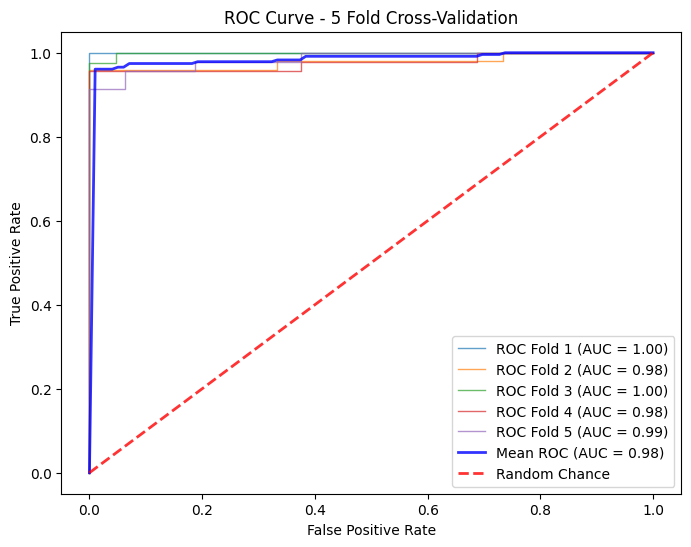

In [124]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
# X = x
X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [125]:
y.value_counts()

1    225
0     88
Name: Diagnosis, dtype: int64

In [ ]:
Thoda rest karlijiye warna rest in peace ho jayegene

# Dimensionlaity Reduction and Feature Selection Techniques

In [ ]:
# !pip install boruta

In [ ]:
#Applying BORUTA algorithm

# from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import pandas as pd
import numpy as np

# # let's load the load_diabetes() dataset from sklearn
# X, y = load_diabetes(return_X_y=True, as_frame=True)

# let's initialize a RF model 
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
model.fit(x,y)

# let's initialize Boruta
feat_selector = BorutaPy(
    verbose=2,
    estimator=model,
    n_estimators='auto',
    max_iter=10  # number of iterations to perform
   
)

# train Boruta
# N.B.: X and y must be numpy arrays
feat_selector.fit(np.array(x), np.array(y))

# print support and ranking for each feature
print("\n------Support and Ranking for each feature------")
for i in range(len(feat_selector.support_)):
    if feat_selector.support_[i]:
        print("Passes the test: ", X.columns[i],
              " - Ranking: ", feat_selector.ranking_[i])
    else:
        print("Doesn't pass the test: ",
              X.columns[i], " - Ranking: ", feat_selector.ranking_[i])
        
        
        
sel_col = pd.Series(feat_selector.ranking_,index=x.columns)
sel_col.sort_values(inplace=True)



sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly



brt15 = sel_col[sel_col.values<16]
brt15.index

In [ ]:
sel_col = pd.Series(feat_selector.ranking_,index=x.columns)
sel_col.sort_values(inplace=True)

In [ ]:
sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly

In [ ]:
df2.info()

In [ ]:
brt15 = sel_col[sel_col.values<16]
brt15.index

In [ ]:
# ruk jaana yaha....

## Shap Value

In [ ]:
# !pip install shap

In [ ]:
import shap
model.fit(x_train,y_train)
explainer = shap.Explainer(model.predict, x_test)
shap_values = explainer(x_test)


In [ ]:
shap.plots.bar(shap_values)

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
shap.plots.beeswarm(shap_values)

In [ ]:
cols =["Appendix_Diameter","Alvarado_Score","Paedriatic_Appendicitis_Score","Thrombocyte_Count","Coughing_Pain","CRP",
       "WBC_Count","Height","Peritonitis_binary"] 
cols

In [ ]:
# error

## Information Gain

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x,y,random_state=0)
feat_importance = pd.Series(importance, x.columns[0:len(x.columns)])
feat_importance.plot(kind='barh',color = 'teal')

In [ ]:
mutual_info = pd.Series(importance)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

In [ ]:
# from sklearn.feature_selection import SelectKBest
# sel_five_cols = SelectKBest(mutual_info_classif, k=0.9)
# sel_five_cols.fit(x_train, y_train)
# x_train.columns[sel_five_cols.get_support()]

In [ ]:
cols = mutual_info[mutual_info>0].index
cols
# x = x.loc[:,cols]
# x.shape

In [ ]:
df3 = df.loc[:,cols]
df3.dropna(inplace =True)

In [ ]:
df3.shape

# Applying Fisher Score for feature selection

In [ ]:
# pip install skfeature-chappers

In [ ]:
# from skfeature.feat_selection import fisher_score
from skfeature.function.similarity_based import fisher_score
ranks = fisher_score.fisher_score(np.array(x),np.array(y))
feat_importance = pd.Series(ranks, x.columns[0:len(x.columns)])
fi = feat_importance.sort_values()
fi.plot(kind='barh',color = 'teal')
cols = ranks[ranks<25]

In [ ]:
cols

In [ ]:
x_= x.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_.columns)
df3.shape

## Variance Threshold as Feature Selection

In [ ]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.2)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

In [ ]:
v_threshold = VarianceThreshold(threshold=0.4)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

## Chi-square Test

In [ ]:
x.columns
non_cat = ["Age","BMI","Height","Weight","Appendix_Diameter","RBC_Count","Body_Temperature"]
x1 = x.drop(non_cat,axis=1)

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
#Convert to catregorial data by converting data to integers
X_cat = x1.astype(int)

#three features with highest chi-squared statistics are selected
chi2_features = SelectKBest(chi2, k =15)
X_best_features = chi2_features.fit_transform(X_cat,y)

#Reduced features
print('Original feature number :',X_cat.shape[1])
print('Reduced feature number :',X_best_features.shape[1])

In [ ]:
X_best_features
selected_features = x1.columns[:][chi2_features.get_support()] 
print("\nSelected Features:") 
print(selected_features)

In [ ]:
non_cat(Index)

In [ ]:
cols = df2.columns
num_cols = df._get_numeric_data().columns
print(num_cols)
# Out[68]: Index([u'0', u'1', u'2'], dtype='object')
list(set(cols) - set(num_cols))